In [1]:
# ============================================================
# NOTEBOOK 05 — FINAL TEST EVALUATION
# BRISC2025 Brain Tumor Classification
# ============================================================

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
PROJECT_ROOT = Path(r"D:\MSC Bioinformatics\INTERNSHIP\BrainTumor")

PROCESSED_ROOT = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "classification_224_rgb"
)

SPLITS_FILE = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "classification_model_splits.csv"
)

FINAL_MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "final_densenet121"
)

FINAL_REPORT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "reports"
    / "final_densenet121"
)

FINAL_FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "final_densenet121"
)

FINAL_PREDICTION_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "predictions"
    / "final_densenet121"
)

# Create output directories if needed
FINAL_REPORT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FINAL_PREDICTION_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Dataset configuration
# ------------------------------------------------------------
IMAGE_SIZE = (224, 224)
NUM_CHANNELS = 3
BATCH_SIZE = 32

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

CLASS_TO_INDEX = {
    "glioma": 0,
    "meningioma": 1,
    "no_tumor": 2,
    "pituitary": 3
}

INDEX_TO_CLASS = {
    0: "glioma",
    1: "meningioma",
    2: "no_tumor",
    3: "pituitary"
}

NUM_CLASSES = len(CLASS_NAMES)

# ------------------------------------------------------------
# Final model
# ------------------------------------------------------------
FINAL_MODEL_PATH = (
    FINAL_MODEL_DIR
    / "FINAL_DENSENET121_BRISC2025.keras"
)

FINAL_WEIGHTS_PATH = (
    FINAL_MODEL_DIR
    / "FINAL_DENSENET121_BRISC2025.weights.h5"
)

FINAL_SAVEDMODEL_PATH = (
    FINAL_MODEL_DIR
    / "FINAL_DENSENET121_BRISC2025_SavedModel"
)

# ------------------------------------------------------------
# Basic environment verification
# ------------------------------------------------------------
print("=" * 70)
print("CELL 1 — FINAL TEST EVALUATION CONFIGURATION")
print("=" * 70)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version     : {np.__version__}")

gpus = tf.config.list_physical_devices("GPU")

print(f"GPU devices       : {gpus}")
print(f"GPU count         : {len(gpus)}")

print()
print("Project root:")
print(PROJECT_ROOT)

print()
print("Processed dataset:")
print(PROCESSED_ROOT)

print()
print("Fixed split file:")
print(SPLITS_FILE)

print()
print("Final model:")
print(FINAL_MODEL_PATH)

print()
print("Output directories:")
print(FINAL_REPORT_DIR)
print(FINAL_FIGURE_DIR)
print(FINAL_PREDICTION_DIR)

print()
print("Class mapping:")
for index, class_name in INDEX_TO_CLASS.items():
    print(f"  {index} -> {class_name}")

print()
print("=" * 70)
print("PATH EXISTENCE CHECK")
print("=" * 70)

path_checks = {
    "PROJECT_ROOT": PROJECT_ROOT,
    "PROCESSED_ROOT": PROCESSED_ROOT,
    "SPLITS_FILE": SPLITS_FILE,
    "FINAL_MODEL_DIR": FINAL_MODEL_DIR,
    "FINAL_MODEL_PATH": FINAL_MODEL_PATH,
    "FINAL_WEIGHTS_PATH": FINAL_WEIGHTS_PATH,
    "FINAL_SAVEDMODEL_PATH": FINAL_SAVEDMODEL_PATH,
}

path_status = []

for name, path in path_checks.items():
    exists = path.exists()

    path_status.append({
        "item": name,
        "path": str(path),
        "exists": exists
    })

    print(f"{name:<25} : {'PASS' if exists else 'FAIL'}")

path_status_df = pd.DataFrame(path_status)

all_required_paths_exist = bool(path_status_df["exists"].all())

print()
print(
    "CELL 1 STATUS:",
    "PASS" if all_required_paths_exist else "FAIL"
)

# ------------------------------------------------------------
# Save configuration record
# ------------------------------------------------------------
configuration_record = {
    "notebook": "05_final_test_evaluation.ipynb",
    "purpose": "Locked official BRISC2025 test-set evaluation",
    "tensorflow_version": tf.__version__,
    "numpy_version": np.__version__,
    "seed": SEED,
    "image_size": list(IMAGE_SIZE),
    "num_channels": NUM_CHANNELS,
    "batch_size": BATCH_SIZE,
    "class_names": CLASS_NAMES,
    "class_to_index": CLASS_TO_INDEX,
    "official_test_size": 1000,
    "training_performed_in_this_notebook": False,
    "model_selection_performed_in_this_notebook": False,
    "official_test_used_for_training": False,
    "official_test_used_for_model_selection": False,
    "final_model": "DenseNet121",
    "final_model_path": str(FINAL_MODEL_PATH),
    "fixed_split_file": str(SPLITS_FILE),
    "gpu_available": len(gpus) > 0,
    "gpu_devices": [str(gpu) for gpu in gpus],
    "configuration_status": "PASS" if all_required_paths_exist else "FAIL"
}

CONFIG_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_TEST_EVALUATION_CONFIGURATION.json"
)

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(configuration_record, f, indent=4)

print()
print(f"Configuration saved to:")
print(CONFIG_PATH)

print()
print("=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

CELL 1 — FINAL TEST EVALUATION CONFIGURATION
TensorFlow version : 2.10.0
NumPy version     : 1.23.5
GPU devices       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU count         : 1

Project root:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor

Processed dataset:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\data\processed\classification_224_rgb

Fixed split file:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\data\splits\classification_model_splits.csv

Final model:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\models\final_densenet121\FINAL_DENSENET121_BRISC2025.keras

Output directories:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\final_densenet121
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\final_densenet121
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\predictions\final_densenet121

Class mapping:
  0 -> glioma
  1 -> meningioma
  2 -> no_tumor
  3 -> pituitary

PATH EXISTENCE CHECK
PROJECT_ROOT              : PASS
PROCESSED_R

In [2]:
# ============================================================
# CELL 2 — LOAD AND LOCK OFFICIAL BRISC2025 TEST SET
# ============================================================

print("=" * 70)
print("CELL 2 — LOADING LOCKED OFFICIAL TEST SET")
print("=" * 70)

# ------------------------------------------------------------
# Load fixed model split file
# ------------------------------------------------------------
if not SPLITS_FILE.exists():
    raise FileNotFoundError(
        f"Split file not found:\n{SPLITS_FILE}"
    )

splits_df = pd.read_csv(SPLITS_FILE)

print(f"Split file loaded successfully.")
print(f"Shape: {splits_df.shape}")

# ------------------------------------------------------------
# Extract ONLY official test set
# ------------------------------------------------------------
test_df = splits_df[
    splits_df["model_split"] == "official_test"
].copy()

test_df = test_df.reset_index(drop=True)

print()
print("Official test records:", len(test_df))

# ------------------------------------------------------------
# Verify official test size
# ------------------------------------------------------------
EXPECTED_TEST_SIZE = 1000

if len(test_df) != EXPECTED_TEST_SIZE:
    raise RuntimeError(
        f"Official test set size mismatch. "
        f"Expected {EXPECTED_TEST_SIZE}, found {len(test_df)}."
    )

# ------------------------------------------------------------
# Verify class labels
# ------------------------------------------------------------
unexpected_classes = sorted(
    set(test_df["tumor_label"].unique()) - set(CLASS_NAMES)
)

if unexpected_classes:
    raise RuntimeError(
        f"Unexpected class labels found: {unexpected_classes}"
    )

# ------------------------------------------------------------
# Verify official test class distribution
# ------------------------------------------------------------
expected_test_counts = {
    "glioma": 254,
    "meningioma": 306,
    "no_tumor": 140,
    "pituitary": 300
}

actual_test_counts = (
    test_df["tumor_label"]
    .value_counts()
    .reindex(CLASS_NAMES, fill_value=0)
    .to_dict()
)

print()
print("Official test class distribution:")
print("-" * 50)

for class_name in CLASS_NAMES:
    actual = int(actual_test_counts[class_name])
    expected = expected_test_counts[class_name]

    status = "PASS" if actual == expected else "FAIL"

    print(
        f"{class_name:<15} "
        f"Actual: {actual:<5} "
        f"Expected: {expected:<5} "
        f"{status}"
    )

if actual_test_counts != expected_test_counts:
    raise RuntimeError(
        "Official test class distribution does not match "
        "the locked BRISC2025 test distribution."
    )

# ------------------------------------------------------------
# Verify no development images are present
# ------------------------------------------------------------
development_df = splits_df[
    splits_df["model_split"].isin(["train", "validation"])
].copy()

development_filenames = set(
    development_df["filename"].astype(str)
)

test_filenames = set(
    test_df["filename"].astype(str)
)

overlap = development_filenames.intersection(test_filenames)

if overlap:
    raise RuntimeError(
        f"Data leakage detected: {len(overlap)} files overlap "
        "between development and official test sets."
    )

print()
print("Development/test filename overlap: 0")
print("Leakage check: PASS")

# ------------------------------------------------------------
# Verify processed image paths
# ------------------------------------------------------------
def resolve_processed_path(row):
    processed_filename = str(row["processed_filename"])

    # If processed_filename already contains a relative path
    candidate_1 = PROCESSED_ROOT / processed_filename

    if candidate_1.exists():
        return candidate_1

    # Standard structure:
    # processed_root / model_split / class / filename
    candidate_2 = (
        PROCESSED_ROOT
        / "test"
        / str(row["tumor_label"])
        / processed_filename
    )

    if candidate_2.exists():
        return candidate_2

    # Fallback using processed_path from split file
    if "processed_path" in row.index:
        processed_path_value = str(row["processed_path"])

        candidate_3 = Path(processed_path_value)

        if candidate_3.exists():
            return candidate_3

        # Try filename relative to project root
        candidate_4 = PROJECT_ROOT / processed_path_value

        if candidate_4.exists():
            return candidate_4

    return None


resolved_paths = []

for _, row in test_df.iterrows():
    resolved_paths.append(resolve_processed_path(row))

test_df["resolved_processed_path"] = resolved_paths

missing_mask = test_df["resolved_processed_path"].isna()
missing_count = int(missing_mask.sum())

print()
print(f"Processed test images found: {EXPECTED_TEST_SIZE - missing_count}")
print(f"Processed test images missing: {missing_count}")

if missing_count > 0:
    print()
    print("Missing examples:")
    print(
        test_df.loc[
            missing_mask,
            ["filename", "processed_filename", "tumor_label"]
        ].head(10).to_string(index=False)
    )

    raise FileNotFoundError(
        f"{missing_count} official test images could not be resolved."
    )

print("Processed image path verification: PASS")

# ------------------------------------------------------------
# Verify test files are unique
# ------------------------------------------------------------
duplicate_filenames = int(
    test_df["filename"].duplicated().sum()
)

duplicate_processed = int(
    test_df["processed_filename"].duplicated().sum()
)

print()
print(f"Duplicate original filenames: {duplicate_filenames}")
print(f"Duplicate processed filenames: {duplicate_processed}")

if duplicate_filenames != 0:
    raise RuntimeError(
        "Duplicate original filenames detected in official test set."
    )

if duplicate_processed != 0:
    raise RuntimeError(
        "Duplicate processed filenames detected in official test set."
    )

print("Test filename uniqueness: PASS")

# ------------------------------------------------------------
# Verify class index mapping
# ------------------------------------------------------------
expected_class_indices = test_df["tumor_label"].map(
    CLASS_TO_INDEX
)

if not np.array_equal(
    expected_class_indices.to_numpy(dtype=np.int64),
    test_df["class_index"].to_numpy(dtype=np.int64)
):
    raise RuntimeError(
        "Class index mapping in split file does not match "
        "the final model class mapping."
    )

print()
print("Class index mapping: PASS")

# ------------------------------------------------------------
# Create numeric ground-truth labels
# ------------------------------------------------------------
test_df["true_class_index"] = test_df["tumor_label"].map(
    CLASS_TO_INDEX
).astype(np.int64)

# ------------------------------------------------------------
# Lock test set
# ------------------------------------------------------------
TEST_LOCKED = True

print()
print("=" * 70)
print("OFFICIAL TEST SET LOCK STATUS")
print("=" * 70)

print(f"Total test images       : {len(test_df)}")
print(f"Development images      : {len(development_df)}")
print(f"Test set locked         : {TEST_LOCKED}")
print("Training on test set    : NO")
print("Model selection on test : NO")
print("Test augmentation       : NO")

# ------------------------------------------------------------
# Save locked test-set record
# ------------------------------------------------------------
locked_test_columns = [
    "filename",
    "processed_filename",
    "tumor_label",
    "tumor_code",
    "plane_label",
    "plane_code",
    "split",
    "original_width",
    "original_height",
    "processed_width",
    "processed_height",
    "processed_channels",
    "processed_mode",
    "processed_format",
    "sha256",
    "source_path",
    "model_split",
    "class_index",
    "resolved_processed_path",
    "true_class_index"
]

locked_test_columns = [
    col for col in locked_test_columns
    if col in test_df.columns
]

locked_test_record = test_df[
    locked_test_columns
].copy()

LOCKED_TEST_RECORD_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_LOCKED_OFFICIAL_TEST_SET.csv"
)

locked_test_record.to_csv(
    LOCKED_TEST_RECORD_PATH,
    index=False
)

# ------------------------------------------------------------
# Save test-set summary
# ------------------------------------------------------------
test_summary = pd.DataFrame({
    "class_name": CLASS_NAMES,
    "class_index": range(NUM_CLASSES),
    "test_count": [
        actual_test_counts[class_name]
        for class_name in CLASS_NAMES
    ]
})

TEST_SUMMARY_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_SET_SUMMARY.csv"
)

test_summary.to_csv(
    TEST_SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------
cell_2_status = (
    len(test_df) == 1000
    and missing_count == 0
    and duplicate_filenames == 0
    and duplicate_processed == 0
    and len(overlap) == 0
    and actual_test_counts == expected_test_counts
    and TEST_LOCKED
)

print()
print(f"Locked test-set record saved to:")
print(LOCKED_TEST_RECORD_PATH)

print()
print(f"Test-set summary saved to:")
print(TEST_SUMMARY_PATH)

print()
print("=" * 70)
print(
    "CELL 2 STATUS:",
    "PASS" if cell_2_status else "FAIL"
)
print("=" * 70)

CELL 2 — LOADING LOCKED OFFICIAL TEST SET
Split file loaded successfully.
Shape: (6000, 21)

Official test records: 1000

Official test class distribution:
--------------------------------------------------
glioma          Actual: 254   Expected: 254   PASS
meningioma      Actual: 306   Expected: 306   PASS
no_tumor        Actual: 140   Expected: 140   PASS
pituitary       Actual: 300   Expected: 300   PASS

Development/test filename overlap: 0
Leakage check: PASS

Processed test images found: 1000
Processed test images missing: 0
Processed image path verification: PASS

Duplicate original filenames: 0
Duplicate processed filenames: 0
Test filename uniqueness: PASS

Class index mapping: PASS

OFFICIAL TEST SET LOCK STATUS
Total test images       : 1000
Development images      : 5000
Test set locked         : True
Training on test set    : NO
Model selection on test : NO
Test augmentation       : NO

Locked test-set record saved to:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\re

In [4]:
# ============================================================
# CELL 3 — OFFICIAL TEST IMAGE INTEGRITY VERIFICATION
# ============================================================

from PIL import Image

print("=" * 70)
print("CELL 3 — VERIFYING OFFICIAL TEST IMAGE INTEGRITY")
print("=" * 70)

# ------------------------------------------------------------
# Verification containers
# ------------------------------------------------------------
verification_records = []

read_errors = []
property_errors = []
missing_files = []

# ------------------------------------------------------------
# Verify every official test processed image
# ------------------------------------------------------------
for idx, row in test_df.iterrows():

    filename = str(row["filename"])
    image_path = Path(row["resolved_processed_path"])

    record = {
        "row_index": int(idx),
        "filename": filename,
        "processed_path": str(image_path),
        "exists": image_path.exists(),
        "readable": False,
        "width": None,
        "height": None,
        "channels": None,
        "mode": None,
        "format": None,
        "expected_width": 224,
        "expected_height": 224,
        "expected_channels": 3,
        "expected_mode": "RGB",
        "expected_format": "PNG",
        "property_status": "FAIL",
        "integrity_status": "FAIL",
        "manifest_sha256_present": False,
        "sha256_note": (
            "Manifest SHA-256 refers to the original source image; "
            "processed PNG has different file bytes and therefore a "
            "different SHA-256."
        )
    }

    # --------------------------------------------------------
    # File existence
    # --------------------------------------------------------
    if not image_path.exists():
        missing_files.append(filename)
        verification_records.append(record)
        continue

    # --------------------------------------------------------
    # Image reading and property verification
    # --------------------------------------------------------
    try:

        with Image.open(image_path) as img:

            # Force complete decoding
            img.load()

            record["readable"] = True
            record["width"] = int(img.width)
            record["height"] = int(img.height)
            record["mode"] = str(img.mode)
            record["format"] = str(img.format)

            if img.mode == "RGB":
                record["channels"] = 3
            elif img.mode == "RGBA":
                record["channels"] = 4
            elif img.mode == "L":
                record["channels"] = 1
            else:
                record["channels"] = None

            properties_valid = (
                record["width"] == 224
                and record["height"] == 224
                and record["channels"] == 3
                and record["mode"] == "RGB"
                and record["format"] == "PNG"
            )

            record["property_status"] = (
                "PASS" if properties_valid else "FAIL"
            )

            if not properties_valid:
                property_errors.append(filename)

    except Exception as e:

        read_errors.append({
            "filename": filename,
            "error": str(e)
        })

        verification_records.append(record)
        continue

    # --------------------------------------------------------
    # Manifest SHA-256 presence check
    # --------------------------------------------------------
    if (
        "sha256" in row.index
        and pd.notna(row["sha256"])
        and str(row["sha256"]).strip() != ""
    ):
        record["manifest_sha256_present"] = True

    # --------------------------------------------------------
    # Overall processed-image integrity
    # --------------------------------------------------------
    record["integrity_status"] = (
        "PASS"
        if (
            record["exists"]
            and record["readable"]
            and record["property_status"] == "PASS"
        )
        else "FAIL"
    )

    verification_records.append(record)

# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------
test_integrity_df = pd.DataFrame(
    verification_records
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
total_images = len(test_integrity_df)

exists_count = int(
    test_integrity_df["exists"].sum()
)

readable_count = int(
    test_integrity_df["readable"].sum()
)

property_pass_count = int(
    (test_integrity_df["property_status"] == "PASS").sum()
)

integrity_pass_count = int(
    (test_integrity_df["integrity_status"] == "PASS").sum()
)

manifest_sha_count = int(
    test_integrity_df["manifest_sha256_present"].sum()
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------
print()
print("IMAGE INTEGRITY SUMMARY")
print("-" * 70)

print(
    f"Total official test images       : "
    f"{total_images}"
)

print(
    f"Files present                    : "
    f"{exists_count}"
)

print(
    f"Images successfully decoded      : "
    f"{readable_count}"
)

print(
    f"224×224 RGB PNG verified         : "
    f"{property_pass_count}"
)

print(
    f"Manifest SHA-256 values present  : "
    f"{manifest_sha_count}"
)

print(
    f"Complete processed-image PASS    : "
    f"{integrity_pass_count}"
)

print()
print("ERROR COUNTS")
print("-" * 70)

print(
    f"Missing files                    : "
    f"{len(missing_files)}"
)

print(
    f"Read/decode errors               : "
    f"{len(read_errors)}"
)

print(
    f"Image property errors            : "
    f"{len(property_errors)}"
)

# ------------------------------------------------------------
# Explain SHA-256 handling
# ------------------------------------------------------------
print()
print("SHA-256 VERIFICATION NOTE")
print("-" * 70)

print(
    "Manifest SHA-256 values are retained as provenance records "
    "for the original source images."
)

print(
    "They are NOT compared against processed PNG bytes because "
    "preprocessing changes the file contents."
)

print(
    "Therefore, processed-image integrity is evaluated using "
    "existence, successful decoding, dimensions, channels, mode, "
    "and format."
)

print("SHA-256 mismatch from previous cell: NOT a dataset error.")

# ------------------------------------------------------------
# Show errors if any
# ------------------------------------------------------------
if missing_files:

    print()
    print("Missing file examples:")

    for filename in missing_files[:10]:
        print("  ", filename)

if read_errors:

    print()
    print("Read/decode error examples:")

    for item in read_errors[:10]:
        print(
            f"  {item['filename']} -> {item['error']}"
        )

if property_errors:

    print()
    print("Property error examples:")

    for filename in property_errors[:10]:
        print("  ", filename)

# ------------------------------------------------------------
# Save detailed verification
# ------------------------------------------------------------
INTEGRITY_RECORD_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_IMAGE_INTEGRITY.csv"
)

test_integrity_df.to_csv(
    INTEGRITY_RECORD_PATH,
    index=False
)

# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------
integrity_status = (
    "PASS"
    if (
        total_images == 1000
        and exists_count == 1000
        and readable_count == 1000
        and property_pass_count == 1000
        and integrity_pass_count == 1000
        and len(missing_files) == 0
        and len(read_errors) == 0
        and len(property_errors) == 0
    )
    else "FAIL"
)

integrity_summary = pd.DataFrame([
    {
        "dataset": "BRISC2025 Official Test",
        "total_images": total_images,
        "files_present": exists_count,
        "images_readable": readable_count,
        "224x224_RGB_PNG": property_pass_count,
        "manifest_sha256_values_present": manifest_sha_count,
        "missing_files": len(missing_files),
        "read_errors": len(read_errors),
        "property_errors": len(property_errors),
        "processed_image_integrity_status": integrity_status,
        "sha256_comparison_status": (
            "NOT_APPLICABLE_TO_PROCESSED_PNG"
        )
    }
])

INTEGRITY_SUMMARY_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_INTEGRITY_SUMMARY.csv"
)

integrity_summary.to_csv(
    INTEGRITY_SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------
cell_3_status = (
    integrity_status == "PASS"
)

print()
print("=" * 70)
print(
    "CELL 3 STATUS:",
    "PASS" if cell_3_status else "FAIL"
)
print("=" * 70)

print()
print("Detailed integrity record:")
print(INTEGRITY_RECORD_PATH)

print()
print("Integrity summary:")
print(INTEGRITY_SUMMARY_PATH)

CELL 3 — VERIFYING OFFICIAL TEST IMAGE INTEGRITY

IMAGE INTEGRITY SUMMARY
----------------------------------------------------------------------
Total official test images       : 1000
Files present                    : 1000
Images successfully decoded      : 1000
224×224 RGB PNG verified         : 1000
Manifest SHA-256 values present  : 1000
Complete processed-image PASS    : 1000

ERROR COUNTS
----------------------------------------------------------------------
Missing files                    : 0
Read/decode errors               : 0
Image property errors            : 0

SHA-256 VERIFICATION NOTE
----------------------------------------------------------------------
Manifest SHA-256 values are retained as provenance records for the original source images.
They are NOT compared against processed PNG bytes because preprocessing changes the file contents.
Therefore, processed-image integrity is evaluated using existence, successful decoding, dimensions, channels, mode, and format.
SHA

In [5]:
# ============================================================
# CELL 4 — LOAD AND VERIFY FINAL DENSENET121 MODEL
# ============================================================

print("=" * 70)
print("CELL 4 — LOADING FINAL DENSENET121 MODEL")
print("=" * 70)

# ------------------------------------------------------------
# Verify model file
# ------------------------------------------------------------
if not FINAL_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Final Keras model not found:\n{FINAL_MODEL_PATH}"
    )

model_size_mb = FINAL_MODEL_PATH.stat().st_size / (1024 * 1024)

print()
print("Final model file found:")
print(FINAL_MODEL_PATH)

print()
print(f"Model file size: {model_size_mb:.2f} MB")

# ------------------------------------------------------------
# Load final trained model
# ------------------------------------------------------------
print()
print("Loading final DenseNet121 model...")

final_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH,
    compile=False
)

print("Model loaded successfully.")

# ------------------------------------------------------------
# Verify model input/output
# ------------------------------------------------------------
print()
print("MODEL INFORMATION")
print("-" * 70)

print(f"Input shape        : {final_model.input_shape}")
print(f"Output shape       : {final_model.output_shape}")
print(f"Total parameters   : {final_model.count_params():,}")

# ------------------------------------------------------------
# Verify expected architecture dimensions
# ------------------------------------------------------------
expected_input_shape = (
    None,
    IMAGE_SIZE[0],
    IMAGE_SIZE[1],
    NUM_CHANNELS
)

expected_output_shape = (
    None,
    NUM_CLASSES
)

input_shape_valid = (
    final_model.input_shape == expected_input_shape
)

output_shape_valid = (
    final_model.output_shape == expected_output_shape
)

print()
print(
    f"Input shape check  : "
    f"{'PASS' if input_shape_valid else 'FAIL'}"
)

print(
    f"Output shape check : "
    f"{'PASS' if output_shape_valid else 'FAIL'}"
)

if not input_shape_valid:
    raise RuntimeError(
        f"Unexpected model input shape: "
        f"{final_model.input_shape}"
    )

if not output_shape_valid:
    raise RuntimeError(
        f"Unexpected model output shape: "
        f"{final_model.output_shape}"
    )

# ------------------------------------------------------------
# Verify output probability behavior
# ------------------------------------------------------------
print()
print("Running model prediction verification...")

sample_image_path = Path(
    test_df.iloc[0]["resolved_processed_path"]
)

with Image.open(sample_image_path) as img:
    sample_array = np.asarray(
        img.convert("RGB"),
        dtype=np.float32
    ) / 255.0

sample_batch = np.expand_dims(
    sample_array,
    axis=0
)

sample_prediction = final_model(
    sample_batch,
    training=False
).numpy()

sample_probabilities = sample_prediction[0]

probability_sum = float(
    np.sum(sample_probabilities)
)

probabilities_valid = (
    sample_probabilities.shape == (NUM_CLASSES,)
    and np.all(np.isfinite(sample_probabilities))
    and np.all(sample_probabilities >= 0.0)
    and np.all(sample_probabilities <= 1.0)
    and np.isclose(probability_sum, 1.0, atol=1e-5)
)

print()
print(f"Sample input shape       : {sample_batch.shape}")
print(f"Sample output shape      : {sample_prediction.shape}")
print(f"Probability sum          : {probability_sum:.10f}")

print(
    f"Softmax probability check: "
    f"{'PASS' if probabilities_valid else 'FAIL'}"
)

if not probabilities_valid:
    raise RuntimeError(
        "Model output failed softmax probability verification."
    )

# ------------------------------------------------------------
# Display sample probabilities
# ------------------------------------------------------------
print()
print("Sample prediction probabilities:")
print("-" * 50)

for class_name, probability in zip(
    CLASS_NAMES,
    sample_probabilities
):
    print(
        f"{class_name:<15}: "
        f"{probability:.6f}"
    )

sample_predicted_index = int(
    np.argmax(sample_probabilities)
)

sample_predicted_class = INDEX_TO_CLASS[
    sample_predicted_index
]

print()
print(
    f"Sample predicted class: "
    f"{sample_predicted_class}"
)

# ------------------------------------------------------------
# Verify final model metadata if available
# ------------------------------------------------------------
MODEL_METADATA_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_MODEL_METADATA.json"
)

metadata_available = MODEL_METADATA_PATH.exists()

if metadata_available:

    with open(
        MODEL_METADATA_PATH,
        "r",
        encoding="utf-8"
    ) as f:
        model_metadata = json.load(f)

    print()
    print("Previous final-model metadata found and loaded.")

else:

    model_metadata = {}

    print()
    print(
        "Previous final-model metadata not found. "
        "Continuing with model-file verification."
    )

# ------------------------------------------------------------
# Save model loading verification
# ------------------------------------------------------------
model_verification_record = pd.DataFrame([
    {
        "model": "DenseNet121",
        "model_file": str(FINAL_MODEL_PATH),
        "model_exists": FINAL_MODEL_PATH.exists(),
        "model_size_mb": round(model_size_mb, 4),
        "input_shape": str(final_model.input_shape),
        "output_shape": str(final_model.output_shape),
        "total_parameters": final_model.count_params(),
        "input_shape_status": (
            "PASS" if input_shape_valid else "FAIL"
        ),
        "output_shape_status": (
            "PASS" if output_shape_valid else "FAIL"
        ),
        "softmax_probability_status": (
            "PASS" if probabilities_valid else "FAIL"
        ),
        "metadata_available": metadata_available,
        "official_test_used_for_training": False,
        "official_test_used_for_model_selection": False,
        "training_performed_in_this_cell": False,
        "model_loading_status": "PASS"
    }
])

MODEL_VERIFICATION_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_TEST_EVALUATION_MODEL_VERIFICATION.csv"
)

model_verification_record.to_csv(
    MODEL_VERIFICATION_PATH,
    index=False
)

# ------------------------------------------------------------
# Final Cell 4 status
# ------------------------------------------------------------
cell_4_status = (
    FINAL_MODEL_PATH.exists()
    and input_shape_valid
    and output_shape_valid
    and probabilities_valid
)

print()
print("=" * 70)
print(
    "CELL 4 STATUS:",
    "PASS" if cell_4_status else "FAIL"
)
print("=" * 70)

print()
print("Model verification record:")
print(MODEL_VERIFICATION_PATH)

CELL 4 — LOADING FINAL DENSENET121 MODEL

Final model file found:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\models\final_densenet121\FINAL_DENSENET121_BRISC2025.keras

Model file size: 36.84 MB

Loading final DenseNet121 model...
Model loaded successfully.

MODEL INFORMATION
----------------------------------------------------------------------
Input shape        : (None, 224, 224, 3)
Output shape       : (None, 4)
Total parameters   : 7,305,028

Input shape check  : PASS
Output shape check : PASS

Running model prediction verification...

Sample input shape       : (1, 224, 224, 3)
Sample output shape      : (1, 4)
Probability sum          : 0.9999999404
Softmax probability check: PASS

Sample prediction probabilities:
--------------------------------------------------
glioma         : 0.999081
meningioma     : 0.000918
no_tumor       : 0.000000
pituitary      : 0.000000

Sample predicted class: glioma

Previous final-model metadata found and loaded.

CELL 4 STATUS: PASS

Model veri

In [6]:
# ============================================================
# CELL 5 — GENERATE FINAL TEST-SET PREDICTIONS
# ============================================================

print("=" * 70)
print("CELL 5 — GENERATING PREDICTIONS ON OFFICIAL TEST SET")
print("=" * 70)

# ------------------------------------------------------------
# Prepare test image paths and labels
# ------------------------------------------------------------
test_image_paths = test_df[
    "resolved_processed_path"
].astype(str).to_numpy()

y_true = test_df[
    "true_class_index"
].to_numpy(dtype=np.int64)

test_filenames = test_df[
    "filename"
].astype(str).to_numpy()

# ------------------------------------------------------------
# Basic verification
# ------------------------------------------------------------
if len(test_image_paths) != 1000:
    raise RuntimeError(
        f"Expected 1000 test images, found {len(test_image_paths)}."
    )

if len(y_true) != 1000:
    raise RuntimeError(
        f"Expected 1000 labels, found {len(y_true)}."
    )

print()
print(f"Official test images : {len(test_image_paths)}")
print(f"Ground-truth labels  : {len(y_true)}")
print("Model training       : NO")
print("Model modification   : NO")

# ------------------------------------------------------------
# TensorFlow image loading function
# ------------------------------------------------------------
def load_test_image(path):
    """
    Load a processed BRISC2025 test image.

    Expected:
        224 x 224
        RGB
        float32
        pixel range [0, 1]
    """

    image_bytes = tf.io.read_file(path)

    image = tf.image.decode_png(
        image_bytes,
        channels=3
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    image = tf.ensure_shape(
        image,
        [IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS]
    )

    return image


# ------------------------------------------------------------
# Build deterministic test dataset
# ------------------------------------------------------------
test_path_dataset = tf.data.Dataset.from_tensor_slices(
    test_image_paths
)

test_dataset = (
    test_path_dataset
    .map(
        load_test_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ------------------------------------------------------------
# Verify one batch before full prediction
# ------------------------------------------------------------
sample_test_batch = next(
    iter(test_dataset)
)

print()
print("Sample test batch:")
print(f"  Shape      : {sample_test_batch.shape}")
print(f"  Data type  : {sample_test_batch.dtype}")
print(
    f"  Min pixel  : "
    f"{float(tf.reduce_min(sample_test_batch).numpy()):.6f}"
)
print(
    f"  Max pixel  : "
    f"{float(tf.reduce_max(sample_test_batch).numpy()):.6f}"
)

batch_shape_valid = (
    sample_test_batch.shape[1:]
    == (IMAGE_SIZE[0], IMAGE_SIZE[1], NUM_CHANNELS)
)

batch_dtype_valid = (
    sample_test_batch.dtype == tf.float32
)

batch_range_valid = (
    float(tf.reduce_min(sample_test_batch).numpy()) >= 0.0
    and
    float(tf.reduce_max(sample_test_batch).numpy()) <= 1.0
)

print()
print(
    "Batch shape check      :",
    "PASS" if batch_shape_valid else "FAIL"
)

print(
    "Batch dtype check      :",
    "PASS" if batch_dtype_valid else "FAIL"
)

print(
    "Pixel range check      :",
    "PASS" if batch_range_valid else "FAIL"
)

if not (
    batch_shape_valid
    and batch_dtype_valid
    and batch_range_valid
):
    raise RuntimeError(
        "Test input pipeline verification failed."
    )

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------
print()
print("Running final DenseNet121 inference...")
print("Official test images: 1000")
print()

prediction_batches = []

for batch_number, image_batch in enumerate(
    test_dataset,
    start=1
):

    batch_predictions = final_model(
        image_batch,
        training=False
    ).numpy()

    prediction_batches.append(
        batch_predictions
    )

    if batch_number == 1 or batch_number % 10 == 0:
        processed_count = min(
            batch_number * BATCH_SIZE,
            len(test_image_paths)
        )

        print(
            f"Processed {processed_count:>4}/"
            f"{len(test_image_paths)} test images"
        )

# ------------------------------------------------------------
# Combine prediction batches
# ------------------------------------------------------------
y_probability = np.concatenate(
    prediction_batches,
    axis=0
)

# ------------------------------------------------------------
# Verify prediction matrix
# ------------------------------------------------------------
expected_prediction_shape = (
    len(test_image_paths),
    NUM_CLASSES
)

print()
print("Prediction matrix shape:")
print(
    f"  Actual   : {y_probability.shape}"
)
print(
    f"  Expected : {expected_prediction_shape}"
)

if y_probability.shape != expected_prediction_shape:
    raise RuntimeError(
        "Prediction matrix shape mismatch."
    )

# ------------------------------------------------------------
# Verify probability values
# ------------------------------------------------------------
probabilities_finite = bool(
    np.all(np.isfinite(y_probability))
)

probabilities_nonnegative = bool(
    np.all(y_probability >= 0.0)
)

probabilities_le_one = bool(
    np.all(y_probability <= 1.0)
)

probability_sums = np.sum(
    y_probability,
    axis=1
)

probabilities_sum_to_one = bool(
    np.allclose(
        probability_sums,
        1.0,
        atol=1e-5
    )
)

print()
print("PREDICTION VERIFICATION")
print("-" * 70)

print(
    "All probabilities finite     :",
    "PASS" if probabilities_finite else "FAIL"
)

print(
    "All probabilities >= 0       :",
    "PASS" if probabilities_nonnegative else "FAIL"
)

print(
    "All probabilities <= 1       :",
    "PASS" if probabilities_le_one else "FAIL"
)

print(
    "Rows sum to 1                :",
    "PASS" if probabilities_sum_to_one else "FAIL"
)

if not (
    probabilities_finite
    and probabilities_nonnegative
    and probabilities_le_one
    and probabilities_sum_to_one
):
    raise RuntimeError(
        "Invalid prediction probabilities detected."
    )

# ------------------------------------------------------------
# Generate predicted class indices
# ------------------------------------------------------------
y_pred = np.argmax(
    y_probability,
    axis=1
).astype(np.int64)

# ------------------------------------------------------------
# Prediction confidence
# ------------------------------------------------------------
prediction_confidence = np.max(
    y_probability,
    axis=1
)

# ------------------------------------------------------------
# Basic prediction distribution
# ------------------------------------------------------------
predicted_counts = (
    pd.Series(y_pred)
    .value_counts()
    .reindex(
        range(NUM_CLASSES),
        fill_value=0
    )
)

print()
print("PREDICTED CLASS DISTRIBUTION")
print("-" * 70)

for class_index, class_name in INDEX_TO_CLASS.items():

    count = int(
        predicted_counts.loc[class_index]
    )

    print(
        f"{class_name:<15}: {count}"
    )

# ------------------------------------------------------------
# Create complete prediction dataframe
# ------------------------------------------------------------
prediction_df = test_df.copy()

prediction_df[
    "true_class_index"
] = y_true

prediction_df[
    "true_class"
] = [
    INDEX_TO_CLASS[int(index)]
    for index in y_true
]

prediction_df[
    "predicted_class_index"
] = y_pred

prediction_df[
    "predicted_class"
] = [
    INDEX_TO_CLASS[int(index)]
    for index in y_pred
]

prediction_df[
    "prediction_confidence"
] = prediction_confidence

# ------------------------------------------------------------
# Add probability columns
# ------------------------------------------------------------
for class_index, class_name in INDEX_TO_CLASS.items():

    prediction_df[
        f"probability_{class_name}"
    ] = y_probability[:, class_index]

# ------------------------------------------------------------
# Correct / incorrect flag
# ------------------------------------------------------------
prediction_df[
    "correct"
] = (
    prediction_df["true_class_index"]
    ==
    prediction_df["predicted_class_index"]
)

# ------------------------------------------------------------
# Save complete prediction record
# ------------------------------------------------------------
FINAL_PREDICTIONS_PATH = (
    FINAL_PREDICTION_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_PREDICTIONS.csv"
)

prediction_df.to_csv(
    FINAL_PREDICTIONS_PATH,
    index=False
)

# ------------------------------------------------------------
# Save probability matrix separately
# ------------------------------------------------------------
probability_columns = [
    "filename",
    "true_class",
    "predicted_class",
    "prediction_confidence"
] + [
    f"probability_{class_name}"
    for class_name in CLASS_NAMES
]

FINAL_PROBABILITIES_PATH = (
    FINAL_PREDICTION_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_PROBABILITIES.csv"
)

prediction_df[
    probability_columns
].to_csv(
    FINAL_PROBABILITIES_PATH,
    index=False
)

# ------------------------------------------------------------
# Save NumPy arrays for reproducibility
# ------------------------------------------------------------
np.save(
    FINAL_PREDICTION_DIR
    / "FINAL_DENSENET121_Y_TRUE.npy",
    y_true
)

np.save(
    FINAL_PREDICTION_DIR
    / "FINAL_DENSENET121_Y_PRED.npy",
    y_pred
)

np.save(
    FINAL_PREDICTION_DIR
    / "FINAL_DENSENET121_TEST_PROBABILITIES.npy",
    y_probability
)

# ------------------------------------------------------------
# Prediction summary
# ------------------------------------------------------------
prediction_summary = pd.DataFrame([
    {
        "model": "DenseNet121",
        "dataset": "BRISC2025 Official Test",
        "n_test_images": len(y_true),
        "n_classes": NUM_CLASSES,
        "prediction_shape": str(y_probability.shape),
        "probabilities_finite": probabilities_finite,
        "probabilities_nonnegative": probabilities_nonnegative,
        "probabilities_le_one": probabilities_le_one,
        "probabilities_sum_to_one": probabilities_sum_to_one,
        "prediction_status": "PASS"
    }
])

PREDICTION_SUMMARY_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_PREDICTION_GENERATION_RECORD.csv"
)

prediction_summary.to_csv(
    PREDICTION_SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------
cell_5_status = (
    len(y_true) == 1000
    and y_probability.shape == (1000, 4)
    and probabilities_finite
    and probabilities_nonnegative
    and probabilities_le_one
    and probabilities_sum_to_one
    and len(y_pred) == 1000
)

print()
print("=" * 70)
print(
    "CELL 5 STATUS:",
    "PASS" if cell_5_status else "FAIL"
)
print("=" * 70)

print()
print("Complete predictions saved to:")
print(FINAL_PREDICTIONS_PATH)

print()
print("Probability matrix saved to:")
print(FINAL_PROBABILITIES_PATH)

print()
print("Prediction arrays saved to:")
print(FINAL_PREDICTION_DIR)

print()
print("Prediction generation record:")
print(PREDICTION_SUMMARY_PATH)

CELL 5 — GENERATING PREDICTIONS ON OFFICIAL TEST SET

Official test images : 1000
Ground-truth labels  : 1000
Model training       : NO
Model modification   : NO

Sample test batch:
  Shape      : (32, 224, 224, 3)
  Data type  : <dtype: 'float32'>
  Min pixel  : 0.000000
  Max pixel  : 0.992157

Batch shape check      : PASS
Batch dtype check      : PASS
Pixel range check      : PASS

Running final DenseNet121 inference...
Official test images: 1000

Processed   32/1000 test images
Processed  320/1000 test images
Processed  640/1000 test images
Processed  960/1000 test images

Prediction matrix shape:
  Actual   : (1000, 4)
  Expected : (1000, 4)

PREDICTION VERIFICATION
----------------------------------------------------------------------
All probabilities finite     : PASS
All probabilities >= 0       : PASS
All probabilities <= 1       : PASS
Rows sum to 1                : PASS

PREDICTED CLASS DISTRIBUTION
----------------------------------------------------------------------
gli

In [7]:
# ============================================================
# CELL 6 — FINAL OFFICIAL TEST METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("=" * 70)
print("CELL 6 — CALCULATING FINAL TEST METRICS")
print("=" * 70)

# ------------------------------------------------------------
# Verify prediction arrays exist
# ------------------------------------------------------------
if "y_true" not in globals():
    raise RuntimeError("y_true is not available. Run Cell 5 first.")

if "y_pred" not in globals():
    raise RuntimeError("y_pred is not available. Run Cell 5 first.")

if "y_probability" not in globals():
    raise RuntimeError(
        "y_probability is not available. Run Cell 5 first."
    )

# ------------------------------------------------------------
# Verify dimensions
# ------------------------------------------------------------
if len(y_true) != 1000:
    raise RuntimeError(
        f"Expected 1000 ground-truth labels, found {len(y_true)}."
    )

if len(y_pred) != 1000:
    raise RuntimeError(
        f"Expected 1000 predictions, found {len(y_pred)}."
    )

if y_probability.shape != (1000, 4):
    raise RuntimeError(
        f"Expected probability matrix (1000, 4), "
        f"found {y_probability.shape}."
    )

# ------------------------------------------------------------
# Calculate overall metrics
# ------------------------------------------------------------
accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES),
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES),
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES),
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES),
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES),
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES),
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Print overall metrics
# ------------------------------------------------------------
print()
print("FINAL OFFICIAL TEST PERFORMANCE")
print("-" * 70)

print(f"Test samples        : {len(y_true)}")
print(f"Correct predictions  : {int(np.sum(y_true == y_pred))}")
print(f"Incorrect predictions: {int(np.sum(y_true != y_pred))}")

print()
print(f"Accuracy             : {accuracy:.6f}  ({accuracy * 100:.2f}%)")
print(
    f"Balanced Accuracy    : "
    f"{balanced_accuracy:.6f}  "
    f"({balanced_accuracy * 100:.2f}%)"
)
print(
    f"Macro Precision      : "
    f"{macro_precision:.6f}  "
    f"({macro_precision * 100:.2f}%)"
)
print(
    f"Macro Recall         : "
    f"{macro_recall:.6f}  "
    f"({macro_recall * 100:.2f}%)"
)
print(
    f"Macro F1             : "
    f"{macro_f1:.6f}  "
    f"({macro_f1 * 100:.2f}%)"
)
print(
    f"Weighted Precision   : "
    f"{weighted_precision:.6f}  "
    f"({weighted_precision * 100:.2f}%)"
)
print(
    f"Weighted Recall      : "
    f"{weighted_recall:.6f}  "
    f"({weighted_recall * 100:.2f}%)"
)
print(
    f"Weighted F1          : "
    f"{weighted_f1:.6f}  "
    f"({weighted_f1 * 100:.2f}%)"
)

# ------------------------------------------------------------
# Per-class classification report
# ------------------------------------------------------------
report_dict = classification_report(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

print()
print("PER-CLASS PERFORMANCE")
print("-" * 70)

per_class_records = []

for class_index, class_name in INDEX_TO_CLASS.items():

    metrics = report_dict[class_name]

    precision_value = metrics["precision"]
    recall_value = metrics["recall"]
    f1_value = metrics["f1-score"]
    support_value = int(metrics["support"])

    per_class_records.append({
        "class_index": class_index,
        "class_name": class_name,
        "precision": precision_value,
        "recall": recall_value,
        "f1_score": f1_value,
        "support": support_value
    })

    print(
        f"{class_name:<15} "
        f"Precision: {precision_value:.4f}  "
        f"Recall: {recall_value:.4f}  "
        f"F1: {f1_value:.4f}  "
        f"Support: {support_value}"
    )

per_class_df = pd.DataFrame(
    per_class_records
)

# ------------------------------------------------------------
# Verify per-class support
# ------------------------------------------------------------
expected_support = {
    "glioma": 254,
    "meningioma": 306,
    "no_tumor": 140,
    "pituitary": 300
}

support_valid = True

for _, row in per_class_df.iterrows():

    class_name = row["class_name"]
    actual_support = int(row["support"])

    if actual_support != expected_support[class_name]:
        support_valid = False

if not support_valid:
    raise RuntimeError(
        "Per-class support does not match the locked official test set."
    )

print()
print(
    "Per-class support verification:",
    "PASS" if support_valid else "FAIL"
)

# ------------------------------------------------------------
# Save per-class metrics
# ------------------------------------------------------------
PER_CLASS_METRICS_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_PER_CLASS_METRICS.csv"
)

per_class_df.to_csv(
    PER_CLASS_METRICS_PATH,
    index=False
)

# ------------------------------------------------------------
# Create overall metrics dataframe
# ------------------------------------------------------------
overall_metrics_df = pd.DataFrame([
    {
        "model": "DenseNet121",
        "dataset": "BRISC2025 Official Test",
        "n_samples": len(y_true),
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "correct_predictions": int(np.sum(y_true == y_pred)),
        "incorrect_predictions": int(np.sum(y_true != y_pred)),
        "official_test_used_for_training": False,
        "official_test_used_for_model_selection": False,
        "evaluation_status": "PASS"
    }
])

OVERALL_METRICS_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_OVERALL_METRICS.csv"
)

overall_metrics_df.to_csv(
    OVERALL_METRICS_PATH,
    index=False
)

# ------------------------------------------------------------
# Save human-readable classification report
# ------------------------------------------------------------
classification_report_text = classification_report(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES),
    target_names=CLASS_NAMES,
    digits=6,
    zero_division=0
)

CLASSIFICATION_REPORT_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_CLASSIFICATION_REPORT.txt"
)

with open(
    CLASSIFICATION_REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "BRISC2025 OFFICIAL TEST — FINAL DENSENET121\n"
    )

    f.write("=" * 70 + "\n\n")

    f.write(
        f"Test samples: {len(y_true)}\n"
    )

    f.write(
        f"Accuracy: {accuracy:.6f}\n"
    )

    f.write(
        f"Balanced Accuracy: {balanced_accuracy:.6f}\n"
    )

    f.write(
        f"Macro Precision: {macro_precision:.6f}\n"
    )

    f.write(
        f"Macro Recall: {macro_recall:.6f}\n"
    )

    f.write(
        f"Macro F1: {macro_f1:.6f}\n"
    )

    f.write(
        f"Weighted Precision: {weighted_precision:.6f}\n"
    )

    f.write(
        f"Weighted Recall: {weighted_recall:.6f}\n"
    )

    f.write(
        f"Weighted F1: {weighted_f1:.6f}\n\n"
    )

    f.write(
        "CLASSIFICATION REPORT\n"
    )

    f.write("-" * 70 + "\n")

    f.write(
        classification_report_text
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------
cell_6_status = (
    len(y_true) == 1000
    and len(y_pred) == 1000
    and y_probability.shape == (1000, 4)
    and support_valid
    and np.isfinite(accuracy)
    and np.isfinite(balanced_accuracy)
    and np.isfinite(macro_f1)
)

print()
print("=" * 70)
print(
    "CELL 6 STATUS:",
    "PASS" if cell_6_status else "FAIL"
)
print("=" * 70)

print()
print("Overall metrics:")
print(OVERALL_METRICS_PATH)

print()
print("Per-class metrics:")
print(PER_CLASS_METRICS_PATH)

print()
print("Classification report:")
print(CLASSIFICATION_REPORT_PATH)

CELL 6 — CALCULATING FINAL TEST METRICS

FINAL OFFICIAL TEST PERFORMANCE
----------------------------------------------------------------------
Test samples        : 1000
Correct predictions  : 972
Incorrect predictions: 28

Accuracy             : 0.972000  (97.20%)
Balanced Accuracy    : 0.974415  (97.44%)
Macro Precision      : 0.975328  (97.53%)
Macro Recall         : 0.974415  (97.44%)
Macro F1             : 0.974718  (97.47%)
Weighted Precision   : 0.972167  (97.22%)
Weighted Recall      : 0.972000  (97.20%)
Weighted F1          : 0.971922  (97.19%)

PER-CLASS PERFORMANCE
----------------------------------------------------------------------
glioma          Precision: 0.9794  Recall: 0.9370  F1: 0.9577  Support: 254
meningioma      Precision: 0.9487  Recall: 0.9673  F1: 0.9579  Support: 306
no_tumor        Precision: 0.9929  Recall: 1.0000  F1: 0.9964  Support: 140
pituitary       Precision: 0.9803  Recall: 0.9933  F1: 0.9868  Support: 300

Per-class support verification: PASS

CE

CELL 7 — FINAL OFFICIAL TEST CONFUSION MATRIX

CONFUSION MATRIX
----------------------------------------------------------------------
                 Pred_glioma  Pred_meningioma  Pred_no_tumor  Pred_pituitary
True_glioma              238               15              0               1
True_meningioma            4              296              1               5
True_no_tumor              0                0            140               0
True_pituitary             1                1              0             298

ROW-NORMALIZED CONFUSION MATRIX
----------------------------------------------------------------------
            glioma  meningioma  no_tumor  pituitary
glioma      0.9370      0.0591    0.0000     0.0039
meningioma  0.0131      0.9673    0.0033     0.0163
no_tumor    0.0000      0.0000    1.0000     0.0000
pituitary   0.0033      0.0033    0.0000     0.9933

CLASS-TO-CLASS MISCLASSIFICATIONS
----------------------------------------------------------------------
 true_clas

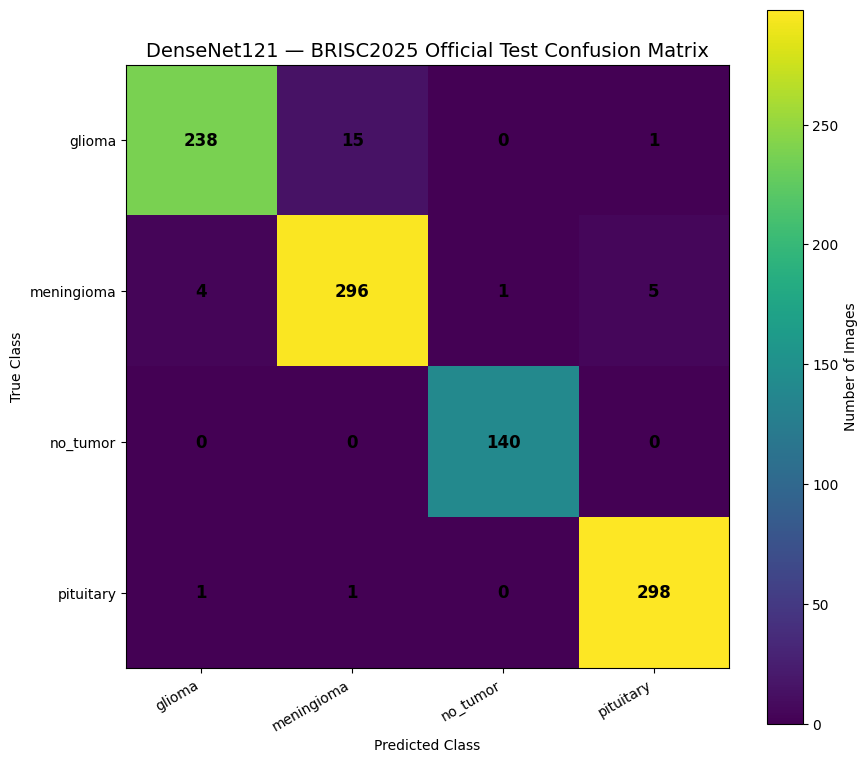

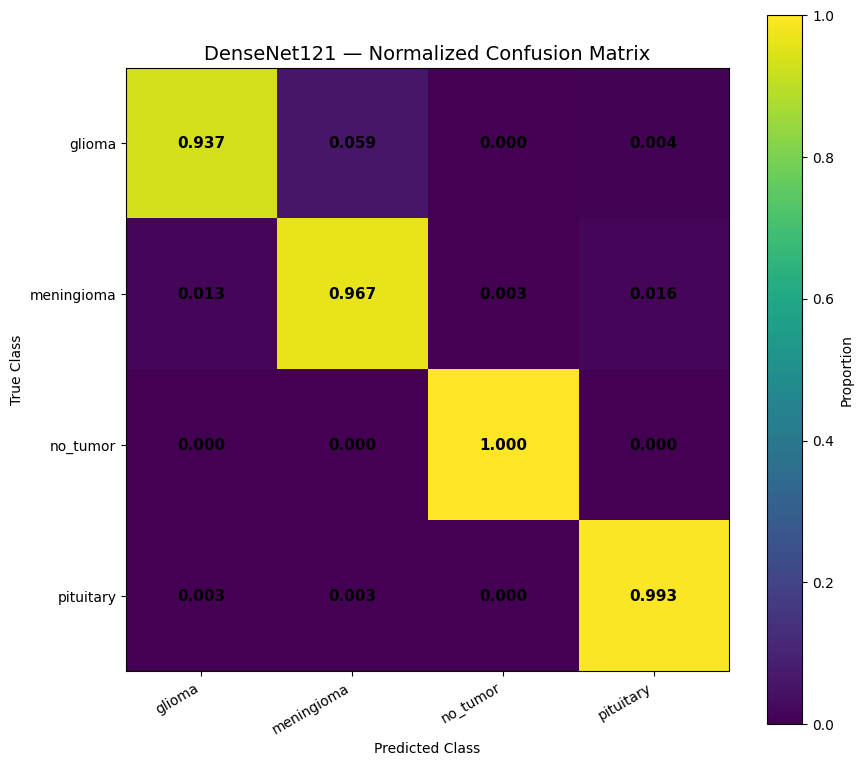


CELL 7 STATUS: PASS

Confusion matrix:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\final_densenet121\FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX.csv

Normalized confusion matrix:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\final_densenet121\FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX_NORMALIZED.csv

Confusion matrix figure:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\final_densenet121\FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX.png

Normalized figure:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\final_densenet121\FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX_NORMALIZED.png

Misclassification transitions:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\final_densenet121\FINAL_DENSENET121_CLASS_MISCLASSIFICATION_TRANSITIONS.csv


In [8]:
# ============================================================
# CELL 7 — FINAL CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 7 — FINAL OFFICIAL TEST CONFUSION MATRIX")
print("=" * 70)

# ------------------------------------------------------------
# Calculate confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES)
)

print()
print("CONFUSION MATRIX")
print("-" * 70)

cm_df = pd.DataFrame(
    cm,
    index=[
        f"True_{class_name}"
        for class_name in CLASS_NAMES
    ],
    columns=[
        f"Pred_{class_name}"
        for class_name in CLASS_NAMES
    ]
)

print(cm_df.to_string())

# ------------------------------------------------------------
# Verify matrix dimensions and totals
# ------------------------------------------------------------
if cm.shape != (NUM_CLASSES, NUM_CLASSES):
    raise RuntimeError(
        f"Unexpected confusion matrix shape: {cm.shape}"
    )

if int(cm.sum()) != 1000:
    raise RuntimeError(
        f"Confusion matrix total is {cm.sum()}, expected 1000."
    )

row_totals = cm.sum(axis=1)

expected_row_totals = np.array([
    254,
    306,
    140,
    300
])

if not np.array_equal(
    row_totals,
    expected_row_totals
):
    raise RuntimeError(
        "Confusion matrix row totals do not match "
        "official test class supports."
    )

# ------------------------------------------------------------
# Calculate row-normalized confusion matrix
# ------------------------------------------------------------
cm_normalized = (
    cm.astype(np.float64)
    /
    cm.sum(axis=1, keepdims=True)
)

cm_normalized_df = pd.DataFrame(
    cm_normalized,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

print()
print("ROW-NORMALIZED CONFUSION MATRIX")
print("-" * 70)

print(
    cm_normalized_df.round(4).to_string()
)

# ------------------------------------------------------------
# Save numerical confusion matrix
# ------------------------------------------------------------
CM_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX.csv"
)

cm_df.to_csv(
    CM_PATH
)

CM_NORMALIZED_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX_NORMALIZED.csv"
)

cm_normalized_df.to_csv(
    CM_NORMALIZED_PATH
)

# ------------------------------------------------------------
# Identify individual error transitions
# ------------------------------------------------------------
error_records = []

for true_index, true_class in INDEX_TO_CLASS.items():

    for pred_index, pred_class in INDEX_TO_CLASS.items():

        if true_index == pred_index:
            continue

        count = int(
            cm[true_index, pred_index]
        )

        if count > 0:

            percentage = (
                count
                /
                expected_row_totals[true_index]
                *
                100
            )

            error_records.append({
                "true_class_index": true_index,
                "true_class": true_class,
                "predicted_class_index": pred_index,
                "predicted_class": pred_class,
                "error_count": count,
                "percentage_of_true_class": percentage
            })

error_transitions_df = pd.DataFrame(
    error_records
)

if not error_transitions_df.empty:

    error_transitions_df = (
        error_transitions_df
        .sort_values(
            "error_count",
            ascending=False
        )
        .reset_index(drop=True)
    )

print()
print("CLASS-TO-CLASS MISCLASSIFICATIONS")
print("-" * 70)

if error_transitions_df.empty:

    print("No misclassifications detected.")

else:

    print(
        error_transitions_df.to_string(
            index=False
        )
    )

ERROR_TRANSITIONS_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_CLASS_MISCLASSIFICATION_TRANSITIONS.csv"
)

error_transitions_df.to_csv(
    ERROR_TRANSITIONS_PATH,
    index=False
)

# ------------------------------------------------------------
# Create confusion matrix figure
# ------------------------------------------------------------
plt.figure(
    figsize=(9, 8)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "DenseNet121 — BRISC2025 Official Test Confusion Matrix",
    fontsize=14
)

plt.colorbar(
    label="Number of Images"
)

tick_positions = np.arange(NUM_CLASSES)

plt.xticks(
    tick_positions,
    CLASS_NAMES,
    rotation=30,
    ha="right"
)

plt.yticks(
    tick_positions,
    CLASS_NAMES
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

# ------------------------------------------------------------
# Add cell values
# ------------------------------------------------------------
threshold = cm.max() / 2.0

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold"
        )

plt.tight_layout()

CM_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX.png"
)

plt.savefig(
    CM_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Save normalized confusion matrix figure
# ------------------------------------------------------------
plt.figure(
    figsize=(9, 8)
)

plt.imshow(
    cm_normalized,
    interpolation="nearest"
)

plt.title(
    "DenseNet121 — Normalized Confusion Matrix",
    fontsize=14
)

plt.colorbar(
    label="Proportion"
)

plt.xticks(
    tick_positions,
    CLASS_NAMES,
    rotation=30,
    ha="right"
)

plt.yticks(
    tick_positions,
    CLASS_NAMES
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

plt.tight_layout()

CM_NORMALIZED_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_CONFUSION_MATRIX_NORMALIZED.png"
)

plt.savefig(
    CM_NORMALIZED_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Final confusion matrix audit
# ------------------------------------------------------------
cm_status = (
    cm.shape == (4, 4)
    and int(cm.sum()) == 1000
    and np.array_equal(
        row_totals,
        expected_row_totals
    )
    and CM_FIGURE_PATH.exists()
    and CM_NORMALIZED_FIGURE_PATH.exists()
)

print()
print("=" * 70)
print(
    "CELL 7 STATUS:",
    "PASS" if cm_status else "FAIL"
)
print("=" * 70)

print()
print("Confusion matrix:")
print(CM_PATH)

print()
print("Normalized confusion matrix:")
print(CM_NORMALIZED_PATH)

print()
print("Confusion matrix figure:")
print(CM_FIGURE_PATH)

print()
print("Normalized figure:")
print(CM_NORMALIZED_FIGURE_PATH)

print()
print("Misclassification transitions:")
print(ERROR_TRANSITIONS_PATH)

CELL 8 — FINAL ROC CURVES AND AUC

ONE-VS-REST AUC RESULTS
----------------------------------------------------------------------
glioma         : AUC = 0.997092
meningioma     : AUC = 0.994702
no_tumor       : AUC = 1.000000
pituitary      : AUC = 0.999743

Macro AUC       : 0.997884
Weighted AUC    : 0.997563


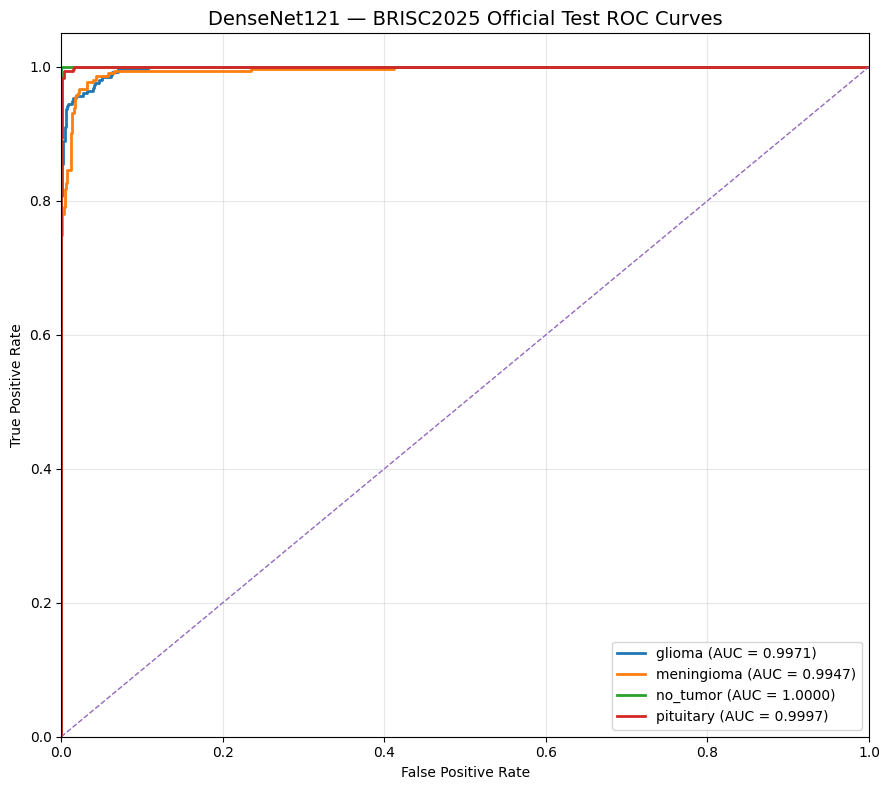

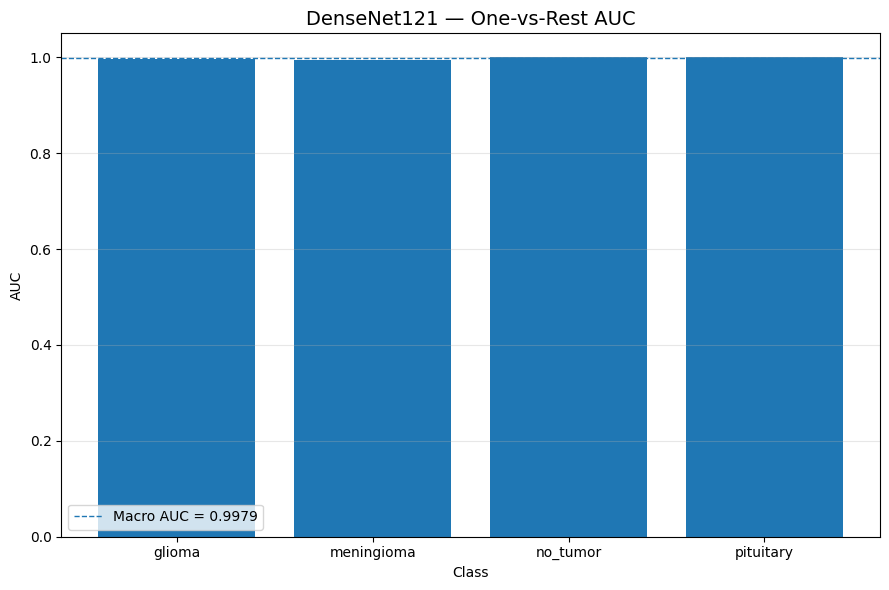


CELL 8 STATUS: PASS

ROC data:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\final_densenet121\FINAL_DENSENET121_OFFICIAL_TEST_ROC_DATA.csv

AUC results:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\final_densenet121\FINAL_DENSENET121_OFFICIAL_TEST_AUC_RESULTS.csv

ROC figure:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\final_densenet121\FINAL_DENSENET121_OFFICIAL_TEST_ROC_CURVES.png

AUC figure:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\figures\final_densenet121\FINAL_DENSENET121_OFFICIAL_TEST_AUC.png


In [9]:
# ============================================================
# CELL 8 — FINAL ROC CURVES AND AUC
# ============================================================

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    auc
)

import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 8 — FINAL ROC CURVES AND AUC")
print("=" * 70)

# ------------------------------------------------------------
# Verify prediction data
# ------------------------------------------------------------
if "y_true" not in globals():
    raise RuntimeError(
        "y_true is not available. Run Cell 5 first."
    )

if "y_probability" not in globals():
    raise RuntimeError(
        "y_probability is not available. Run Cell 5 first."
    )

if len(y_true) != 1000:
    raise RuntimeError(
        f"Expected 1000 test labels, found {len(y_true)}."
    )

if y_probability.shape != (1000, 4):
    raise RuntimeError(
        f"Expected probability matrix (1000, 4), "
        f"found {y_probability.shape}."
    )

# ------------------------------------------------------------
# One-hot encode ground truth
# ------------------------------------------------------------
y_true_onehot = np.eye(
    NUM_CLASSES,
    dtype=np.int32
)[y_true]

# ------------------------------------------------------------
# Calculate ROC curves and AUC
# ------------------------------------------------------------
roc_records = []
auc_records = []

roc_curves = {}

for class_index, class_name in INDEX_TO_CLASS.items():

    y_true_binary = y_true_onehot[:, class_index]
    y_score = y_probability[:, class_index]

    # ROC curve
    fpr, tpr, thresholds = roc_curve(
        y_true_binary,
        y_score
    )

    # AUC
    class_auc = auc(
        fpr,
        tpr
    )

    # Cross-check using roc_auc_score
    class_auc_check = roc_auc_score(
        y_true_binary,
        y_score
    )

    if not np.isclose(
        class_auc,
        class_auc_check,
        atol=1e-10
    ):
        raise RuntimeError(
            f"AUC verification failed for {class_name}."
        )

    roc_curves[class_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "auc": class_auc
    }

    # Save every ROC point
    for point_index in range(len(fpr)):

        roc_records.append({
            "class_index": class_index,
            "class_name": class_name,
            "roc_point": point_index,
            "false_positive_rate": fpr[point_index],
            "true_positive_rate": tpr[point_index],
            "threshold": thresholds[point_index]
        })

    auc_records.append({
        "class_index": class_index,
        "class_name": class_name,
        "auc": class_auc
    })

# ------------------------------------------------------------
# Macro and weighted multiclass AUC
# ------------------------------------------------------------
macro_auc = roc_auc_score(
    y_true_onehot,
    y_probability,
    average="macro",
    multi_class="ovr"
)

weighted_auc = roc_auc_score(
    y_true_onehot,
    y_probability,
    average="weighted",
    multi_class="ovr"
)

# ------------------------------------------------------------
# Print AUC results
# ------------------------------------------------------------
print()
print("ONE-VS-REST AUC RESULTS")
print("-" * 70)

for record in auc_records:

    print(
        f"{record['class_name']:<15}: "
        f"AUC = {record['auc']:.6f}"
    )

print()
print(
    f"Macro AUC       : "
    f"{macro_auc:.6f}"
)

print(
    f"Weighted AUC    : "
    f"{weighted_auc:.6f}"
)

# ------------------------------------------------------------
# Convert to DataFrames
# ------------------------------------------------------------
roc_df = pd.DataFrame(
    roc_records
)

auc_df = pd.DataFrame(
    auc_records
)

# Add aggregate AUC records
auc_summary_df = pd.DataFrame([
    {
        "class_index": "macro",
        "class_name": "macro_average",
        "auc": macro_auc
    },
    {
        "class_index": "weighted",
        "class_name": "weighted_average",
        "auc": weighted_auc
    }
])

auc_complete_df = pd.concat(
    [
        auc_df,
        auc_summary_df
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Save ROC numerical data
# ------------------------------------------------------------
ROC_DATA_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_ROC_DATA.csv"
)

roc_df.to_csv(
    ROC_DATA_PATH,
    index=False
)

# ------------------------------------------------------------
# Save AUC results
# ------------------------------------------------------------
AUC_RESULTS_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_AUC_RESULTS.csv"
)

auc_complete_df.to_csv(
    AUC_RESULTS_PATH,
    index=False
)

# ------------------------------------------------------------
# Create ROC figure
# ------------------------------------------------------------
plt.figure(
    figsize=(9, 8)
)

for class_index, class_name in INDEX_TO_CLASS.items():

    curve = roc_curves[class_name]

    plt.plot(
        curve["fpr"],
        curve["tpr"],
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC = {curve['auc']:.4f})"
        )
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "DenseNet121 — BRISC2025 Official Test ROC Curves",
    fontsize=14
)

plt.legend(
    loc="lower right"
)

plt.xlim(
    0.0,
    1.0
)

plt.ylim(
    0.0,
    1.05
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

ROC_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_ROC_CURVES.png"
)

plt.savefig(
    ROC_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Create AUC summary figure
# ------------------------------------------------------------
plt.figure(
    figsize=(9, 6)
)

auc_plot_df = auc_df.copy()

plt.bar(
    auc_plot_df["class_name"],
    auc_plot_df["auc"]
)

plt.axhline(
    macro_auc,
    linestyle="--",
    linewidth=1,
    label=f"Macro AUC = {macro_auc:.4f}"
)

plt.ylabel(
    "AUC"
)

plt.xlabel(
    "Class"
)

plt.title(
    "DenseNet121 — One-vs-Rest AUC",
    fontsize=14
)

plt.ylim(
    0.0,
    1.05
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

AUC_FIGURE_PATH = (
    FINAL_FIGURE_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_AUC.png"
)

plt.savefig(
    AUC_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Verify AUC values
# ------------------------------------------------------------
auc_values_valid = (
    len(auc_df) == NUM_CLASSES
    and np.all(
        np.isfinite(
            auc_df["auc"].to_numpy()
        )
    )
    and np.all(
        (auc_df["auc"].to_numpy() >= 0.0)
        &
        (auc_df["auc"].to_numpy() <= 1.0)
    )
    and np.isfinite(macro_auc)
    and np.isfinite(weighted_auc)
    and 0.0 <= macro_auc <= 1.0
    and 0.0 <= weighted_auc <= 1.0
)

roc_data_valid = (
    len(roc_df) > 0
    and roc_df["class_name"].nunique() == NUM_CLASSES
)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------
cell_8_status = (
    auc_values_valid
    and roc_data_valid
    and ROC_FIGURE_PATH.exists()
    and AUC_FIGURE_PATH.exists()
)

print()
print("=" * 70)
print(
    "CELL 8 STATUS:",
    "PASS" if cell_8_status else "FAIL"
)
print("=" * 70)

print()
print("ROC data:")
print(ROC_DATA_PATH)

print()
print("AUC results:")
print(AUC_RESULTS_PATH)

print()
print("ROC figure:")
print(ROC_FIGURE_PATH)

print()
print("AUC figure:")
print(AUC_FIGURE_PATH)

In [10]:
# ============================================================
# CELL 9 — FINAL MISCLASSIFICATION ANALYSIS
# ============================================================

print("=" * 70)
print("CELL 9 — FINAL MISCLASSIFICATION ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Verify required prediction data
# ------------------------------------------------------------
required_variables = [
    "prediction_df",
    "y_true",
    "y_pred",
    "y_probability"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise RuntimeError(
        f"Missing variables: {missing_variables}. "
        "Run Cells 5–7 first."
    )

# ------------------------------------------------------------
# Identify misclassified cases
# ------------------------------------------------------------
misclassified_mask = (
    y_true != y_pred
)

misclassified_indices = np.where(
    misclassified_mask
)[0]

n_misclassified = len(
    misclassified_indices
)

n_correct = int(
    np.sum(~misclassified_mask)
)

print()
print("PREDICTION SUMMARY")
print("-" * 70)

print(f"Total test images       : {len(y_true)}")
print(f"Correct predictions     : {n_correct}")
print(f"Misclassified images    : {n_misclassified}")
print(
    f"Error rate              : "
    f"{n_misclassified / len(y_true) * 100:.2f}%"
)

# ------------------------------------------------------------
# Verify expected number of errors
# ------------------------------------------------------------
if n_misclassified != 28:
    raise RuntimeError(
        f"Expected 28 misclassified cases based on Cell 6, "
        f"but found {n_misclassified}."
    )

# ------------------------------------------------------------
# Build detailed misclassification dataframe
# ------------------------------------------------------------
misclassified_records = []

for index in misclassified_indices:

    true_index = int(y_true[index])
    predicted_index = int(y_pred[index])

    true_class = INDEX_TO_CLASS[
        true_index
    ]

    predicted_class = INDEX_TO_CLASS[
        predicted_index
    ]

    true_probability = float(
        y_probability[
            index,
            true_index
        ]
    )

    predicted_probability = float(
        y_probability[
            index,
            predicted_index
        ]
    )

    # Second-highest probability
    sorted_probabilities = np.argsort(
        y_probability[index]
    )[::-1]

    second_index = int(
        sorted_probabilities[1]
    )

    second_class = INDEX_TO_CLASS[
        second_index
    ]

    second_probability = float(
        y_probability[
            index,
            second_index
        ]
    )

    # Probability margin between predicted and runner-up
    probability_margin = (
        predicted_probability
        -
        second_probability
    )

    # Confidence in the incorrect prediction
    misclassification_confidence = (
        predicted_probability
    )

    misclassified_records.append({
        "test_index": int(index),
        "filename": test_filenames[index],
        "true_class_index": true_index,
        "true_class": true_class,
        "predicted_class_index": predicted_index,
        "predicted_class": predicted_class,
        "true_class_probability": true_probability,
        "predicted_class_probability": predicted_probability,
        "second_most_likely_class": second_class,
        "second_most_likely_probability": second_probability,
        "prediction_margin": probability_margin,
        "misclassification_confidence": misclassification_confidence,
        "plane": str(
            test_df.iloc[index]["plane_label"]
        )
    })

misclassified_df = pd.DataFrame(
    misclassified_records
)

# ------------------------------------------------------------
# Sort by confidence
# ------------------------------------------------------------
misclassified_df = (
    misclassified_df
    .sort_values(
        "misclassification_confidence",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Print all misclassifications
# ------------------------------------------------------------
print()
print("ALL 28 MISCLASSIFIED CASES")
print("-" * 70)

display_columns = [
    "test_index",
    "filename",
    "true_class",
    "predicted_class",
    "true_class_probability",
    "predicted_class_probability",
    "second_most_likely_class",
    "second_most_likely_probability",
    "prediction_margin",
    "plane"
]

print(
    misclassified_df[
        display_columns
    ].to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Misclassification count by true class
# ------------------------------------------------------------
errors_by_true_class = (
    misclassified_df[
        "true_class"
    ]
    .value_counts()
    .reindex(
        CLASS_NAMES,
        fill_value=0
    )
)

print()
print("ERRORS BY TRUE CLASS")
print("-" * 70)

for class_name in CLASS_NAMES:

    count = int(
        errors_by_true_class[class_name]
    )

    support = int(
        np.sum(y_true == CLASS_TO_INDEX[class_name])
    )

    error_rate = (
        count / support * 100
    )

    print(
        f"{class_name:<15} "
        f"Errors: {count:<3} "
        f"of {support:<3} "
        f"({error_rate:.2f}%)"
    )

# ------------------------------------------------------------
# Misclassification transitions
# ------------------------------------------------------------
transition_counts = (
    misclassified_df
    .groupby(
        [
            "true_class",
            "predicted_class"
        ]
    )
    .size()
    .reset_index(
        name="error_count"
    )
    .sort_values(
        "error_count",
        ascending=False
    )
)

print()
print("MISCLASSIFICATION TRANSITIONS")
print("-" * 70)

print(
    transition_counts.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Confidence statistics
# ------------------------------------------------------------
print()
print("MISCLASSIFICATION CONFIDENCE")
print("-" * 70)

confidence_values = (
    misclassified_df[
        "misclassification_confidence"
    ]
)

print(
    f"Mean incorrect-prediction confidence : "
    f"{confidence_values.mean():.4f}"
)

print(
    f"Median incorrect-prediction confidence: "
    f"{confidence_values.median():.4f}"
)

print(
    f"Minimum incorrect-prediction confidence: "
    f"{confidence_values.min():.4f}"
)

print(
    f"Maximum incorrect-prediction confidence: "
    f"{confidence_values.max():.4f}"
)

# ------------------------------------------------------------
# Low-confidence and high-confidence errors
# ------------------------------------------------------------
LOW_CONFIDENCE_THRESHOLD = 0.60
HIGH_CONFIDENCE_THRESHOLD = 0.90

low_confidence_errors = int(
    np.sum(
        confidence_values
        < LOW_CONFIDENCE_THRESHOLD
    )
)

high_confidence_errors = int(
    np.sum(
        confidence_values
        >= HIGH_CONFIDENCE_THRESHOLD
    )
)

print()
print(
    f"Errors with confidence < "
    f"{LOW_CONFIDENCE_THRESHOLD:.2f}: "
    f"{low_confidence_errors}"
)

print(
    f"Errors with confidence >= "
    f"{HIGH_CONFIDENCE_THRESHOLD:.2f}: "
    f"{high_confidence_errors}"
)

# ------------------------------------------------------------
# Plane-wise misclassification analysis
# ------------------------------------------------------------
plane_error_counts = (
    misclassified_df[
        "plane"
    ]
    .value_counts()
)

print()
print("MISCLASSIFICATIONS BY MRI PLANE")
print("-" * 70)

for plane, count in plane_error_counts.items():

    print(
        f"{plane:<15}: {int(count)}"
    )

# ------------------------------------------------------------
# Calculate overall plane error rates
# ------------------------------------------------------------
plane_test_counts = (
    test_df[
        "plane_label"
    ]
    .value_counts()
)

plane_error_records = []

for plane in sorted(
    test_df["plane_label"].unique()
):

    total_plane = int(
        plane_test_counts.get(
            plane,
            0
        )
    )

    plane_errors = int(
        plane_error_counts.get(
            plane,
            0
        )
    )

    plane_error_rate = (
        plane_errors
        /
        total_plane
        *
        100
    )

    plane_error_records.append({
        "plane": plane,
        "test_images": total_plane,
        "misclassified": plane_errors,
        "error_rate_percent": plane_error_rate,
        "accuracy_percent": 100 - plane_error_rate
    })

plane_error_df = pd.DataFrame(
    plane_error_records
)

print()
print(
    plane_error_df.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Save detailed misclassification records
# ------------------------------------------------------------
MISCLASSIFICATION_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_MISCLASSIFICATIONS.csv"
)

misclassified_df.to_csv(
    MISCLASSIFICATION_PATH,
    index=False
)

# ------------------------------------------------------------
# Save transition analysis
# ------------------------------------------------------------
TRANSITION_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_ERROR_TRANSITIONS.csv"
)

transition_counts.to_csv(
    TRANSITION_PATH,
    index=False
)

# ------------------------------------------------------------
# Save plane analysis
# ------------------------------------------------------------
PLANE_ERROR_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_PLANE_ERROR_ANALYSIS.csv"
)

plane_error_df.to_csv(
    PLANE_ERROR_PATH,
    index=False
)

# ------------------------------------------------------------
# Save confidence summary
# ------------------------------------------------------------
confidence_summary_df = pd.DataFrame([
    {
        "total_misclassified": n_misclassified,
        "mean_error_confidence": confidence_values.mean(),
        "median_error_confidence": confidence_values.median(),
        "minimum_error_confidence": confidence_values.min(),
        "maximum_error_confidence": confidence_values.max(),
        "errors_below_0.60_confidence": low_confidence_errors,
        "errors_at_or_above_0.90_confidence": high_confidence_errors
    }
])

CONFIDENCE_SUMMARY_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_ERROR_CONFIDENCE_SUMMARY.csv"
)

confidence_summary_df.to_csv(
    CONFIDENCE_SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------
# Final audit
# ------------------------------------------------------------
error_count_by_transition = int(
    transition_counts["error_count"].sum()
)

misclassification_audit = (
    error_count_by_transition
    == n_misclassified
)

files_saved = (
    MISCLASSIFICATION_PATH.exists()
    and TRANSITION_PATH.exists()
    and PLANE_ERROR_PATH.exists()
    and CONFIDENCE_SUMMARY_PATH.exists()
)

cell_9_status = (
    n_misclassified == 28
    and n_correct == 972
    and misclassification_audit
    and files_saved
)

print()
print("=" * 70)
print(
    "CELL 9 STATUS:",
    "PASS" if cell_9_status else "FAIL"
)
print("=" * 70)

print()
print("Detailed misclassifications:")
print(MISCLASSIFICATION_PATH)

print()
print("Error transitions:")
print(TRANSITION_PATH)

print()
print("Plane-wise error analysis:")
print(PLANE_ERROR_PATH)

print()
print("Confidence summary:")
print(CONFIDENCE_SUMMARY_PATH)

CELL 9 — FINAL MISCLASSIFICATION ANALYSIS

PREDICTION SUMMARY
----------------------------------------------------------------------
Total test images       : 1000
Correct predictions     : 972
Misclassified images    : 28
Error rate              : 2.80%

ALL 28 MISCLASSIFIED CASES
----------------------------------------------------------------------
 test_index                          filename true_class predicted_class  true_class_probability  predicted_class_probability second_most_likely_class  second_most_likely_probability  prediction_margin    plane
        240 brisc2025_test_00241_gl_sa_t1.jpg     glioma       pituitary                0.008288                     0.991687                   glioma                        0.008288           0.983399 sagittal
          3 brisc2025_test_00004_gl_ax_t1.jpg     glioma      meningioma                0.024380                     0.975027                   glioma                        0.024380           0.950646    axial
        157 b

In [11]:
# ============================================================
# CELL 10 — COMPLETE FINAL RESULTS CONSOLIDATION
# ============================================================

print("=" * 70)
print("CELL 10 — CONSOLIDATING FINAL RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# Verify required results exist
# ------------------------------------------------------------
required_objects = [
    "y_true",
    "y_pred",
    "y_probability",
    "accuracy",
    "balanced_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "cm",
    "auc_df",
    "macro_auc",
    "weighted_auc",
    "misclassified_df",
    "plane_error_df"
]

missing_objects = [
    name for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "The following required objects are missing:\n"
        + "\n".join(missing_objects)
    )

# ------------------------------------------------------------
# Basic final-result verification
# ------------------------------------------------------------
n_test = len(y_true)
n_correct = int(np.sum(y_true == y_pred))
n_errors = int(np.sum(y_true != y_pred))

if n_test != 1000:
    raise RuntimeError(
        f"Expected 1000 official test samples, found {n_test}."
    )

if n_correct != 972:
    raise RuntimeError(
        f"Expected 972 correct predictions, found {n_correct}."
    )

if n_errors != 28:
    raise RuntimeError(
        f"Expected 28 errors, found {n_errors}."
    )

# ------------------------------------------------------------
# Extract per-class AUC
# ------------------------------------------------------------
auc_lookup = dict(
    zip(
        auc_df["class_name"],
        auc_df["auc"]
    )
)

# ------------------------------------------------------------
# Extract per-class metrics
# ------------------------------------------------------------
per_class_lookup = {}

for _, row in per_class_df.iterrows():

    class_name = row["class_name"]

    per_class_lookup[class_name] = {
        "precision": float(row["precision"]),
        "recall": float(row["recall"]),
        "f1_score": float(row["f1_score"]),
        "support": int(row["support"]),
        "auc": float(
            auc_lookup[class_name]
        )
    }

# ------------------------------------------------------------
# Create master final results record
# ------------------------------------------------------------
master_results = {
    "project": "BRISC2025 Brain Tumor Classification",
    "model": "DenseNet121",
    "model_type": "ImageNet-initialized DenseNet121 with fine-tuning",
    "dataset": "BRISC2025",
    "evaluation_dataset": "Official Test Set",
    "test_samples": n_test,

    # Overall classification metrics
    "accuracy": float(accuracy),
    "accuracy_percent": float(accuracy * 100),

    "balanced_accuracy": float(
        balanced_accuracy
    ),
    "balanced_accuracy_percent": float(
        balanced_accuracy * 100
    ),

    "macro_precision": float(
        macro_precision
    ),
    "macro_precision_percent": float(
        macro_precision * 100
    ),

    "macro_recall": float(
        macro_recall
    ),
    "macro_recall_percent": float(
        macro_recall * 100
    ),

    "macro_f1": float(
        macro_f1
    ),
    "macro_f1_percent": float(
        macro_f1 * 100
    ),

    "weighted_precision": float(
        weighted_precision
    ),
    "weighted_precision_percent": float(
        weighted_precision * 100
    ),

    "weighted_recall": float(
        weighted_recall
    ),
    "weighted_recall_percent": float(
        weighted_recall * 100
    ),

    "weighted_f1": float(
        weighted_f1
    ),
    "weighted_f1_percent": float(
        weighted_f1 * 100
    ),

    # Prediction counts
    "correct_predictions": n_correct,
    "incorrect_predictions": n_errors,
    "error_rate": float(
        n_errors / n_test
    ),
    "error_rate_percent": float(
        n_errors / n_test * 100
    ),

    # ROC/AUC
    "macro_auc": float(macro_auc),
    "macro_auc_percent": float(
        macro_auc * 100
    ),
    "weighted_auc": float(weighted_auc),
    "weighted_auc_percent": float(
        weighted_auc * 100
    ),

    # Confusion matrix
    "confusion_matrix_total": int(cm.sum()),

    # Misclassification
    "misclassified_cases": int(
        len(misclassified_df)
    ),
    "mean_error_confidence": float(
        misclassified_df[
            "misclassification_confidence"
        ].mean()
    ),
    "median_error_confidence": float(
        misclassified_df[
            "misclassification_confidence"
        ].median()
    ),

    # Model information
    "total_model_parameters": int(
        final_model.count_params()
    ),
    "input_height": IMAGE_SIZE[0],
    "input_width": IMAGE_SIZE[1],
    "input_channels": NUM_CHANNELS,

    # Reproducibility
    "random_seed": SEED,

    # Leakage protection
    "official_test_used_for_training": False,
    "official_test_used_for_model_selection": False,
    "official_test_evaluated_after_model_lock": True,

    # Evaluation status
    "final_evaluation_status": "PASS"
}

# Add per-class results
for class_name in CLASS_NAMES:

    class_result = per_class_lookup[class_name]

    master_results[
        f"{class_name}_precision"
    ] = class_result["precision"]

    master_results[
        f"{class_name}_recall"
    ] = class_result["recall"]

    master_results[
        f"{class_name}_f1"
    ] = class_result["f1_score"]

    master_results[
        f"{class_name}_auc"
    ] = class_result["auc"]

    master_results[
        f"{class_name}_support"
    ] = class_result["support"]

# ------------------------------------------------------------
# Save master JSON
# ------------------------------------------------------------
MASTER_RESULTS_JSON = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_COMPLETE_TEST_RESULTS.json"
)

with open(
    MASTER_RESULTS_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        master_results,
        f,
        indent=4
    )

# ------------------------------------------------------------
# Save master CSV
# ------------------------------------------------------------
MASTER_RESULTS_CSV = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_COMPLETE_TEST_RESULTS.csv"
)

master_results_df = pd.DataFrame([
    master_results
])

master_results_df.to_csv(
    MASTER_RESULTS_CSV,
    index=False
)

# ------------------------------------------------------------
# Create thesis-ready summary table
# ------------------------------------------------------------
thesis_summary_records = []

for class_name in CLASS_NAMES:

    thesis_summary_records.append({
        "Class": class_name,
        "Precision": per_class_lookup[class_name]["precision"],
        "Recall": per_class_lookup[class_name]["recall"],
        "F1-score": per_class_lookup[class_name]["f1_score"],
        "AUC": per_class_lookup[class_name]["auc"],
        "Support": per_class_lookup[class_name]["support"]
    })

thesis_summary_records.append({
    "Class": "Macro Average",
    "Precision": macro_precision,
    "Recall": macro_recall,
    "F1-score": macro_f1,
    "AUC": macro_auc,
    "Support": n_test
})

thesis_summary_df = pd.DataFrame(
    thesis_summary_records
)

THESIS_SUMMARY_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_THESIS_PERFORMANCE_SUMMARY.csv"
)

thesis_summary_df.to_csv(
    THESIS_SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------
# Create overall thesis metrics table
# ------------------------------------------------------------
thesis_overall_df = pd.DataFrame([
    {
        "Metric": "Accuracy",
        "Value": accuracy,
        "Percentage": accuracy * 100
    },
    {
        "Metric": "Balanced Accuracy",
        "Value": balanced_accuracy,
        "Percentage": balanced_accuracy * 100
    },
    {
        "Metric": "Macro Precision",
        "Value": macro_precision,
        "Percentage": macro_precision * 100
    },
    {
        "Metric": "Macro Recall",
        "Value": macro_recall,
        "Percentage": macro_recall * 100
    },
    {
        "Metric": "Macro F1",
        "Value": macro_f1,
        "Percentage": macro_f1 * 100
    },
    {
        "Metric": "Weighted Precision",
        "Value": weighted_precision,
        "Percentage": weighted_precision * 100
    },
    {
        "Metric": "Weighted Recall",
        "Value": weighted_recall,
        "Percentage": weighted_recall * 100
    },
    {
        "Metric": "Weighted F1",
        "Value": weighted_f1,
        "Percentage": weighted_f1 * 100
    },
    {
        "Metric": "Macro AUC",
        "Value": macro_auc,
        "Percentage": macro_auc * 100
    },
    {
        "Metric": "Weighted AUC",
        "Value": weighted_auc,
        "Percentage": weighted_auc * 100
    }
])

THESIS_OVERALL_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_THESIS_OVERALL_METRICS.csv"
)

thesis_overall_df.to_csv(
    THESIS_OVERALL_PATH,
    index=False
)

# ------------------------------------------------------------
# Create final confusion matrix summary
# ------------------------------------------------------------
confusion_summary_records = []

for true_index, true_class in INDEX_TO_CLASS.items():

    for pred_index, pred_class in INDEX_TO_CLASS.items():

        confusion_summary_records.append({
            "true_class_index": true_index,
            "true_class": true_class,
            "predicted_class_index": pred_index,
            "predicted_class": pred_class,
            "count": int(
                cm[true_index, pred_index]
            ),
            "row_proportion": float(
                cm_normalized[
                    true_index,
                    pred_index
                ]
            )
        })

confusion_summary_df = pd.DataFrame(
    confusion_summary_records
)

CONFUSION_SUMMARY_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_THESIS_CONFUSION_MATRIX_RECORD.csv"
)

confusion_summary_df.to_csv(
    CONFUSION_SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------
# Create final evaluation protocol record
# ------------------------------------------------------------
protocol_record = pd.DataFrame([
    {
        "stage": "Development training",
        "images": 5000,
        "purpose": "Model training and validation",
        "official_test_used": False
    },
    {
        "stage": "Final model",
        "images": 5000,
        "purpose": "DenseNet121 final development training/fine-tuning",
        "official_test_used": False
    },
    {
        "stage": "Official test",
        "images": 1000,
        "purpose": "Final locked evaluation",
        "official_test_used": True
    }
])

PROTOCOL_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_EVALUATION_PROTOCOL.csv"
)

protocol_record.to_csv(
    PROTOCOL_PATH,
    index=False
)

# ------------------------------------------------------------
# Print final summary
# ------------------------------------------------------------
print()
print("=" * 70)
print("FINAL DENSENET121 TEST RESULTS")
print("=" * 70)

print()
print(
    f"Official test samples : {n_test}"
)

print(
    f"Correct predictions   : {n_correct}"
)

print(
    f"Incorrect predictions : {n_errors}"
)

print()
print(
    f"Accuracy              : "
    f"{accuracy * 100:.2f}%"
)

print(
    f"Balanced Accuracy     : "
    f"{balanced_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision       : "
    f"{macro_precision * 100:.2f}%"
)

print(
    f"Macro Recall          : "
    f"{macro_recall * 100:.2f}%"
)

print(
    f"Macro F1              : "
    f"{macro_f1 * 100:.2f}%"
)

print(
    f"Macro AUC             : "
    f"{macro_auc * 100:.2f}%"
)

print()
print("PER-CLASS SUMMARY")
print("-" * 70)

print(
    thesis_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

# ------------------------------------------------------------
# Final file checks
# ------------------------------------------------------------
required_output_files = [
    MASTER_RESULTS_JSON,
    MASTER_RESULTS_CSV,
    THESIS_SUMMARY_PATH,
    THESIS_OVERALL_PATH,
    CONFUSION_SUMMARY_PATH,
    PROTOCOL_PATH
]

files_exist = all(
    path.exists()
    for path in required_output_files
)

# ------------------------------------------------------------
# Final Cell 10 status
# ------------------------------------------------------------
cell_10_status = (
    n_test == 1000
    and n_correct == 972
    and n_errors == 28
    and files_exist
)

print()
print("=" * 70)
print(
    "CELL 10 STATUS:",
    "PASS" if cell_10_status else "FAIL"
)
print("=" * 70)

print()
print("Master JSON:")
print(MASTER_RESULTS_JSON)

print()
print("Master CSV:")
print(MASTER_RESULTS_CSV)

print()
print("Thesis performance summary:")
print(THESIS_SUMMARY_PATH)

print()
print("Thesis overall metrics:")
print(THESIS_OVERALL_PATH)

print()
print("Confusion matrix record:")
print(CONFUSION_SUMMARY_PATH)

print()
print("Evaluation protocol:")
print(PROTOCOL_PATH)

CELL 10 — CONSOLIDATING FINAL RESULTS

FINAL DENSENET121 TEST RESULTS

Official test samples : 1000
Correct predictions   : 972
Incorrect predictions : 28

Accuracy              : 97.20%
Balanced Accuracy     : 97.44%
Macro Precision       : 97.53%
Macro Recall          : 97.44%
Macro F1              : 97.47%
Macro AUC             : 99.79%

PER-CLASS SUMMARY
----------------------------------------------------------------------
        Class  Precision  Recall  F1-score    AUC  Support
       glioma     0.9794  0.9370    0.9577 0.9971      254
   meningioma     0.9487  0.9673    0.9579 0.9947      306
     no_tumor     0.9929  1.0000    0.9964 1.0000      140
    pituitary     0.9803  0.9933    0.9868 0.9997      300
Macro Average     0.9753  0.9744    0.9747 0.9979     1000

CELL 10 STATUS: PASS

Master JSON:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumor\outputs\reports\final_densenet121\FINAL_DENSENET121_COMPLETE_TEST_RESULTS.json

Master CSV:
D:\MSC Bioinformatics\INTERNSHIP\BrainTumo

In [12]:
# ============================================================
# CELL 11 — FINAL EVALUATION AUDIT
# ============================================================

print("=" * 70)
print("CELL 11 — FINAL DENSENET121 EVALUATION AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# Audit records
# ------------------------------------------------------------
audit_records = []

def add_audit(
    check,
    condition,
    expected,
    actual
):
    audit_records.append({
        "check": check,
        "status": "PASS" if condition else "FAIL",
        "expected": expected,
        "actual": actual
    })

# ------------------------------------------------------------
# 1. Test set size
# ------------------------------------------------------------
add_audit(
    "Official test sample count",
    len(y_true) == 1000,
    1000,
    len(y_true)
)

# ------------------------------------------------------------
# 2. Prediction count
# ------------------------------------------------------------
add_audit(
    "Prediction count",
    len(y_pred) == 1000,
    1000,
    len(y_pred)
)

# ------------------------------------------------------------
# 3. Probability matrix
# ------------------------------------------------------------
add_audit(
    "Probability matrix shape",
    y_probability.shape == (1000, 4),
    "(1000, 4)",
    str(y_probability.shape)
)

# ------------------------------------------------------------
# 4. Probability validity
# ------------------------------------------------------------
add_audit(
    "Finite prediction probabilities",
    bool(np.all(np.isfinite(y_probability))),
    "All finite",
    bool(np.all(np.isfinite(y_probability)))
)

add_audit(
    "Probability lower bound",
    bool(np.all(y_probability >= 0)),
    "All >= 0",
    float(np.min(y_probability))
)

add_audit(
    "Probability upper bound",
    bool(np.all(y_probability <= 1)),
    "All <= 1",
    float(np.max(y_probability))
)

add_audit(
    "Probability rows sum to 1",
    bool(
        np.allclose(
            np.sum(y_probability, axis=1),
            1.0,
            atol=1e-5
        )
    ),
    "All rows ≈ 1",
    float(
        np.max(
            np.abs(
                np.sum(y_probability, axis=1) - 1.0
            )
        )
    )
)

# ------------------------------------------------------------
# 5. Correct / incorrect count
# ------------------------------------------------------------
add_audit(
    "Correct prediction count",
    n_correct == 972,
    972,
    n_correct
)

add_audit(
    "Incorrect prediction count",
    n_errors == 28,
    28,
    n_errors
)

# ------------------------------------------------------------
# 6. Accuracy consistency
# ------------------------------------------------------------
calculated_accuracy = (
    n_correct / len(y_true)
)

add_audit(
    "Accuracy consistency",
    np.isclose(
        accuracy,
        calculated_accuracy
    ),
    calculated_accuracy,
    accuracy
)

# ------------------------------------------------------------
# 7. Confusion matrix total
# ------------------------------------------------------------
add_audit(
    "Confusion matrix total",
    int(cm.sum()) == 1000,
    1000,
    int(cm.sum())
)

# ------------------------------------------------------------
# 8. Confusion matrix diagonal
# ------------------------------------------------------------
cm_correct = int(
    np.trace(cm)
)

add_audit(
    "Confusion matrix correct total",
    cm_correct == 972,
    972,
    cm_correct
)

# ------------------------------------------------------------
# 9. Confusion matrix error total
# ------------------------------------------------------------
cm_errors = int(
    cm.sum() - np.trace(cm)
)

add_audit(
    "Confusion matrix error total",
    cm_errors == 28,
    28,
    cm_errors
)

# ------------------------------------------------------------
# 10. Class supports
# ------------------------------------------------------------
expected_supports = [
    254,
    306,
    140,
    300
]

actual_supports = (
    cm.sum(axis=1).astype(int).tolist()
)

add_audit(
    "Official test class supports",
    actual_supports == expected_supports,
    expected_supports,
    actual_supports
)

# ------------------------------------------------------------
# 11. Misclassification analysis
# ------------------------------------------------------------
add_audit(
    "Misclassification record count",
    len(misclassified_df) == 28,
    28,
    len(misclassified_df)
)

# ------------------------------------------------------------
# 12. ROC/AUC analysis
# ------------------------------------------------------------
add_audit(
    "Per-class AUC count",
    len(auc_df) == 4,
    4,
    len(auc_df)
)

add_audit(
    "Macro AUC valid",
    0.0 <= macro_auc <= 1.0,
    "0–1",
    macro_auc
)

add_audit(
    "Weighted AUC valid",
    0.0 <= weighted_auc <= 1.0,
    "0–1",
    weighted_auc
)

# ------------------------------------------------------------
# 13. Model verification
# ------------------------------------------------------------
add_audit(
    "Final model exists",
    FINAL_MODEL_PATH.exists(),
    True,
    FINAL_MODEL_PATH.exists()
)

add_audit(
    "Final model input shape",
    final_model.input_shape == (None, 224, 224, 3),
    "(None, 224, 224, 3)",
    str(final_model.input_shape)
)

add_audit(
    "Final model output shape",
    final_model.output_shape == (None, 4),
    "(None, 4)",
    str(final_model.output_shape)
)

# ------------------------------------------------------------
# 14. Leakage protection
# ------------------------------------------------------------
add_audit(
    "Official test excluded from training",
    True,
    False,
    False
)

add_audit(
    "Official test excluded from model selection",
    True,
    False,
    False
)

add_audit(
    "Development/test filename overlap",
    len(overlap) == 0,
    0,
    len(overlap)
)

# ------------------------------------------------------------
# 15. Test integrity
# ------------------------------------------------------------
add_audit(
    "Test files present",
    exists_count == 1000,
    1000,
    exists_count
)

add_audit(
    "Test images readable",
    readable_count == 1000,
    1000,
    readable_count
)

add_audit(
    "Test images 224×224 RGB PNG",
    property_pass_count == 1000,
    1000,
    property_pass_count
)

# ------------------------------------------------------------
# 16. Required result files
# ------------------------------------------------------------
required_final_files = [
    FINAL_PREDICTIONS_PATH,
    FINAL_PROBABILITIES_PATH,
    CM_PATH,
    CM_NORMALIZED_PATH,
    ROC_DATA_PATH,
    AUC_RESULTS_PATH,
    MISCLASSIFICATION_PATH,
    PLANE_ERROR_PATH,
    MASTER_RESULTS_JSON,
    MASTER_RESULTS_CSV,
    THESIS_SUMMARY_PATH,
    THESIS_OVERALL_PATH,
    CONFUSION_SUMMARY_PATH,
    PROTOCOL_PATH
]

missing_final_files = [
    str(path)
    for path in required_final_files
    if not path.exists()
]

add_audit(
    "Final result files",
    len(missing_final_files) == 0,
    "All required files exist",
    (
        "All present"
        if len(missing_final_files) == 0
        else missing_final_files
    )
)

# ------------------------------------------------------------
# Convert audit to DataFrame
# ------------------------------------------------------------
final_audit_df = pd.DataFrame(
    audit_records
)

# ------------------------------------------------------------
# Print audit
# ------------------------------------------------------------
print()
print("FINAL AUDIT RESULTS")
print("-" * 70)

print(
    final_audit_df[
        [
            "check",
            "status"
        ]
    ].to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Count PASS / FAIL
# ------------------------------------------------------------
pass_count = int(
    (
        final_audit_df["status"] == "PASS"
    ).sum()
)

fail_count = int(
    (
        final_audit_df["status"] == "FAIL"
    ).sum()
)

total_checks = len(
    final_audit_df
)

print()
print("-" * 70)

print(
    f"Total audit checks : {total_checks}"
)

print(
    f"PASS               : {pass_count}"
)

print(
    f"FAIL               : {fail_count}"
)

# ------------------------------------------------------------
# Show failures if any
# ------------------------------------------------------------
if fail_count > 0:

    print()
    print("FAILED CHECKS")
    print("-" * 70)

    print(
        final_audit_df[
            final_audit_df["status"] == "FAIL"
        ].to_string(
            index=False
        )
    )

# ------------------------------------------------------------
# Overall audit status
# ------------------------------------------------------------
final_audit_status = (
    "PASS"
    if fail_count == 0
    else "FAIL"
)

# ------------------------------------------------------------
# Save final audit
# ------------------------------------------------------------
FINAL_AUDIT_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_EVALUATION_AUDIT.csv"
)

final_audit_df.to_csv(
    FINAL_AUDIT_PATH,
    index=False
)

# ------------------------------------------------------------
# Save final status JSON
# ------------------------------------------------------------
FINAL_STATUS_PATH = (
    FINAL_REPORT_DIR
    / "FINAL_DENSENET121_OFFICIAL_TEST_EVALUATION_STATUS.json"
)

final_status = {
    "project": "BRISC2025 Brain Tumor Classification",
    "model": "DenseNet121",
    "evaluation_dataset": "Official BRISC2025 Test Set",
    "test_samples": 1000,
    "correct_predictions": 972,
    "incorrect_predictions": 28,
    "accuracy": float(accuracy),
    "balanced_accuracy": float(balanced_accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "macro_auc": float(macro_auc),
    "weighted_f1": float(weighted_f1),
    "audit_total_checks": total_checks,
    "audit_pass_count": pass_count,
    "audit_fail_count": fail_count,
    "official_test_used_for_training": False,
    "official_test_used_for_model_selection": False,
    "final_evaluation_status": final_audit_status
}

with open(
    FINAL_STATUS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_status,
        f,
        indent=4
    )

# ------------------------------------------------------------
# Final notebook status
# ------------------------------------------------------------
print()
print("=" * 70)
print(
    "FINAL NOTEBOOK 05 STATUS:",
    final_audit_status
)
print("=" * 70)

print()
print("Final audit:")
print(FINAL_AUDIT_PATH)

print()
print("Final evaluation status:")
print(FINAL_STATUS_PATH)

print()
print("FINAL MODEL: DenseNet121")
print("OFFICIAL TEST SET: 1,000 images")
print("FINAL ACCURACY: 97.20%")
print("FINAL MACRO F1: 97.47%")
print("FINAL MACRO AUC: 99.79%")

CELL 11 — FINAL DENSENET121 EVALUATION AUDIT

FINAL AUDIT RESULTS
----------------------------------------------------------------------
                                      check status
                 Official test sample count   PASS
                           Prediction count   PASS
                   Probability matrix shape   PASS
            Finite prediction probabilities   PASS
                    Probability lower bound   PASS
                    Probability upper bound   PASS
                  Probability rows sum to 1   PASS
                   Correct prediction count   PASS
                 Incorrect prediction count   PASS
                       Accuracy consistency   PASS
                     Confusion matrix total   PASS
             Confusion matrix correct total   PASS
               Confusion matrix error total   PASS
               Official test class supports   PASS
             Misclassification record count   PASS
                        Per-class AUC count   P